In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from tqdm_joblib import tqdm_joblib
from scipy.signal import find_peaks
# =====================================================
# GLOBAL SETTINGS
# =====================================================
SEEDS = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]
# LAMBDAS = [1e-3, 1e-2, 1e-1]
LAMBDAS = [1e-1]
# You can now vary train/test bias independently
# TRAIN_BIAS = [0.0,0.5,1.0]
# TEST_BIAS  = [0.0, 0.5, 1.0]
TRAIN_BIAS = [0.0]
TEST_BIAS  = [0.0]
TRAIN_SIZES = list(range(1, 301))
N_TRAIN_MAX = max(TRAIN_SIZES)
N_TEST = 1000

N_VALUES = list(range(1, 21))
MSE_THRESHOLD = 0.1

# =====================================================
# ANALYTIC FUNCTION
# =====================================================
def analytic_function(x, alpha, r=3):
    x = np.asarray(x)
    alpha = np.asarray(alpha)

    theta = alpha / (2 * r)
    phi = x / (2 * r)

    ct2 = np.cos(theta)**2
    ct4 = ct2**2
    ct6 = ct2**3

    cp2 = np.cos(phi)**2
    cp4 = cp2**2

    terms = (
        32 * cp4 * ct6 
        - 32 * cp4 * ct4 
        - 16 * cp2 * ct4 
        + 16 * cp2 * ct2 
        + 2 * ct2 
        - 1
    )

    return np.prod(terms)

# =====================================================
# IMPROVED BIASING (MULTI-MODE)
# =====================================================
# def sample_biased_x(num_points, dim_x, bias_strength=0.3):
#     """
#     Sample around multiple important regions (multiples of pi).
#     """
#     centers = np.array([-3*np.pi, -2*np.pi, -np.pi, 0, np.pi, 2*np.pi, 3*np.pi])
#     choices = np.random.choice(len(centers), size=num_points)

#     samples = np.zeros((num_points, dim_x))
#     for i in range(num_points):
#         center = centers[choices[i]]
#         samples[i] = np.random.normal(center, bias_strength, size=dim_x)

#     return samples

def one_d_factor(x, alpha_j, r=3):
    theta = alpha_j/(2*r)
    phi = x/(2*r)

    ct2 = np.cos(theta)**2
    ct4 = ct2**2
    ct6 = ct2**3

    cp2 = np.cos(phi)**2
    cp4 = cp2**2

    return (
        32*cp4*ct6
        -32*cp4*ct4
        -16*cp2*ct4
        +16*cp2*ct2
        +2*ct2
        -1
    )

# def get_centers_for_alpha(alpha_j, num_centers=5):
#     grid = np.linspace(-3*np.pi, 3*np.pi, 5000)
#     vals = np.abs(one_d_factor(grid, alpha_j))

#     peaks = []

#     # local maxima
#     for i in range(1, len(grid)-1):
#         if vals[i] >= vals[i-1] and vals[i] >= vals[i+1]:
#             peaks.append(i)

#     # fallback if none found
#     if len(peaks) == 0:
#         peaks = list(np.argsort(vals)[-20:])

#     # sort by value
#     peaks = sorted(peaks, key=lambda i: vals[i], reverse=True)

#     chosen = []
#     min_sep = 0.01

#     for idx in peaks:
#         x = grid[idx]

#         if all(abs(x-c) > min_sep for c in chosen):
#             chosen.append(x)

#         if len(chosen) == num_centers:
#             break

#     # emergency fallback
#     if len(chosen) == 0:
#         chosen = [grid[np.argmax(vals)]]

#     return np.array(chosen)

def get_centers_for_alpha(alpha_j):
    grid = np.linspace(-3*np.pi, 3*np.pi, 20000)
    vals = one_d_factor(grid, alpha_j)

    max_idx, _ = find_peaks(vals)
    min_idx, _ = find_peaks(-vals)

    peaks = np.concatenate([max_idx, min_idx])

    # keep only strong peaks
    peaks = [i for i in peaks if abs(vals[i]) >= 0.9]

    if len(peaks) == 0:
        peaks = [np.argmax(np.abs(vals))]

    peaks = sorted(peaks, key=lambda i: abs(vals[i]), reverse=True)

    chosen = []
    min_sep = 0.05

    for idx in peaks:
        x = grid[idx]
        if all(abs(x-c) > min_sep for c in chosen):
            chosen.append(x)

    return np.array(chosen)

def sample_biased_x(num_points, dim_x, alpha):
    sigma = 0.4 / np.sqrt(dim_x)

    centers_per_dim = [get_centers_for_alpha(a) for a in alpha]

    samples = np.zeros((num_points, dim_x))

    for i in range(num_points):
        for j in range(dim_x):
            centers_j = centers_per_dim[j]

            # choose independently per dimension
            c = np.random.choice(centers_j)

            samples[i, j] = np.random.normal(c, sigma)

    return samples

def generate_mixed_dataset(num_points, dim_x, alpha, bias_fraction):
    n_bias = int(num_points * bias_fraction)
    n_uniform = num_points - n_bias

    xs_uniform = np.random.uniform(-3*np.pi, 3*np.pi, (n_uniform, dim_x))
    xs_bias = sample_biased_x(n_bias, dim_x, alpha)

    xs = np.vstack([xs_uniform, xs_bias])
    np.random.shuffle(xs)

    X = [x for x in xs]
    Y = np.array([analytic_function(x, alpha) for x in X])
    return X, Y

# =====================================================
# KERNEL
# =====================================================
def b_single(xi):
    c = np.cos(xi/6)
    return {
        0: 2*c**2 - 2*c**4,
        2: 0.5 * (1 - c**4),
        -2: 0.5 * (1 - c**4),
        4: (c**4 - c**2),
        -4: (c**4 - c**2),
        6: 0.5 * c**4,
        -6: 0.5 * c**4
    }

def k1(xi, yi):
    bx = b_single(xi)
    by = b_single(yi)
    return sum(bx[l] * by[l] for l in bx)

def analytic_kernel(x, y):
    val = 1.0
    for xi, yi in zip(x, y):
        val *= k1(xi, yi)
    return val

# =====================================================
# KRR
# =====================================================
def krr_fit(K, y, lam):
    return np.linalg.solve(K + (lam)*np.eye(K.shape[0]), y)

# =====================================================
# SINGLE RUN
# =====================================================
def run_single(seed, dim_x, lam, train_bias, test_bias):
    np.random.seed(seed)
    alpha_old = 3*np.pi * np.random.rand(dim_x)*0
    A = np.mean(alpha_old)
    alpha = np.full(dim_x, A)
    # alpha = alpha_old

    X_test, Y_test = generate_mixed_dataset(N_TEST, dim_x, alpha, test_bias)
    X_train_full, Y_train_full = generate_mixed_dataset(N_TRAIN_MAX, dim_x, alpha, train_bias)

    K_train = np.zeros((N_TRAIN_MAX, N_TRAIN_MAX))
    K_test  = np.zeros((N_TEST, N_TRAIN_MAX))

    for i in range(N_TRAIN_MAX):
        for j in range(i, N_TRAIN_MAX):
            val = analytic_kernel(X_train_full[i], X_train_full[j])
            K_train[i,j] = val
            K_train[j,i] = val

    for i in range(N_TEST):
        for j in range(N_TRAIN_MAX):
            K_test[i,j] = analytic_kernel(X_test[i], X_train_full[j])

    train_mse = np.zeros(len(TRAIN_SIZES))
    test_mse = np.zeros(len(TRAIN_SIZES))
    min_eigs = np.zeros(len(TRAIN_SIZES))
    max_eigs = np.zeros(len(TRAIN_SIZES))
    eigvals_all = []
    stop_idx = None
    diag_ratios = np.zeros(len(TRAIN_SIZES))
    off_energies = np.zeros(len(TRAIN_SIZES))
    for ti, n in enumerate(TRAIN_SIZES):
        Ktr = K_train[:n,:n]
        Kte = K_test[:, :n]
        ytr = Y_train_full[:n]
        diag_vals = np.diag(Ktr)
        off_vals = Ktr[~np.eye(n, dtype=bool)]

        diag_mean = np.mean(np.abs(diag_vals))
        off_mean  = np.mean(np.abs(off_vals))

        diag_ratio = off_mean / (diag_mean + 1e-15)

        fro_total = np.linalg.norm(Ktr, 'fro')
        fro_off   = np.linalg.norm(Ktr - np.diag(np.diag(Ktr)), 'fro')

        off_energy = fro_off / (fro_total + 1e-15)
        
        diag_ratios[ti] = diag_ratio
        off_energies[ti] = off_energy
        c = krr_fit(Ktr, ytr, lam/np.sqrt(n))

        pred_train = Ktr @ c
        pred_test  = Kte @ c

        train_mse[ti] = np.mean((ytr - pred_train)**2)
        test_mse[ti] = np.mean((Y_test - pred_test)**2)

        eigvals = np.linalg.eigvalsh(Ktr)
        min_eigs[ti] = np.min(eigvals)
        max_eigs[ti] = np.max(eigvals)
        eigvals_all.append(eigvals.copy())
        if stop_idx is None and test_mse[ti] <= MSE_THRESHOLD:
            stop_idx = ti

    if stop_idx is not None:
        required = TRAIN_SIZES[stop_idx]
        eig_stop_min = min_eigs[stop_idx]
        eig_stop_max = max_eigs[stop_idx]
    else:
        required = np.nan
        eig_stop_min = np.nan
        eig_stop_max = np.nan

    return {
        "train_curve": train_mse,
        "test_curve": test_mse,
        "min_eigs": min_eigs,
        "max_eigs": max_eigs,
        "eigvals_all": eigvals_all,
        "required": required,
        "eig_stop_min": eig_stop_min,
        "eig_stop_max": eig_stop_max,
        "Y_train_full": Y_train_full,
        "Y_test": Y_test,
        "diag_ratios": diag_ratios,
        "off_energies": off_energies
    }

# =====================================================
# MAIN EXPERIMENT
# =====================================================
all_results = {}
summary_log = []

for n in tqdm(N_VALUES, desc="n progress"):
    for lam in LAMBDAS:
        for tb in TRAIN_BIAS:
            for vb in TEST_BIAS:
                # print(f"Running n={n}, λ={lam}, train_bias={tb}, test_bias={vb}")

                # with tqdm_joblib(tqdm(total=len(SEEDS), leave=False)):
                results = Parallel(n_jobs=10)(
                    delayed(run_single)(seed, n, lam, tb, vb)
                    for seed in SEEDS
                )

                train_curves = np.array([r["train_curve"] for r in results])
                test_curves  = np.array([r["test_curve"] for r in results])

                min_eigs = np.array([r["min_eigs"] for r in results])
                max_eigs = np.array([r["max_eigs"] for r in results])

                required = np.array([r["required"] for r in results])

                eig_stop_min = np.array([r["eig_stop_min"] for r in results])
                eig_stop_max = np.array([r["eig_stop_max"] for r in results])
                eigvals_all = [r["eigvals_all"] for r in results]
                Y_train_all = [r["Y_train_full"] for r in results]
                Y_test_all  = [r["Y_test"] for r in results]
                key = (n, lam, tb, vb)

                success_mask = ~np.isnan(required)
                success_rate = np.mean(success_mask)

                # mean only over successful seeds
                req_mean = np.nanmean(required)
                req_std  = np.nanstd(required)

                req_worst = np.nanmax(required)
                # strict version: all seeds must succeed
                if success_rate == 1.0:
                    strict_required = req_mean
                else:
                    strict_required = np.nan
                diag_ratios = np.array([r["diag_ratios"] for r in results])
                off_energies = np.array([r["off_energies"] for r in results])
                all_results[key] = {
                    "train_mean": train_curves.mean(axis=0),
                    "train_std": train_curves.std(axis=0),
                    "train_curves": train_curves,
                    "test_mean": test_curves.mean(axis=0),
                    "test_std": test_curves.std(axis=0),
                    "test_curves": test_curves,
                    "min_eig_mean": min_eigs.mean(axis=0),
                    "max_eig_mean": max_eigs.mean(axis=0),
                    "eigvals_all": eigvals_all,
                    "required_mean": req_mean,
                    "required_std": req_std,

                    "success_rate": success_rate,
                    "num_success": np.sum(success_mask),

                    "strict_required": strict_required,

                    "eig_stop_min_mean": np.nanmean(eig_stop_min),
                    "eig_stop_min_std": np.nanstd(eig_stop_min),

                    "eig_stop_max_mean": np.nanmean(eig_stop_max),
                    "eig_stop_max_std": np.nanstd(eig_stop_max),
                    
                    "worst_required": req_worst,
                    "Y_train_all": Y_train_all,
                    "Y_test_all": Y_test_all,
                    
                    "diag_ratio_mean": diag_ratios.mean(axis=0),
                    "off_energy_mean": off_energies.mean(axis=0)
                }
                
                summary_log.append({
                    "n": n,
                    "lambda": lam,
                    "train_bias": tb,
                    "test_bias": vb,
                    "successes": int(np.sum(success_mask)),
                    "success_rate": float(success_rate),
                    "mean_required": float(req_mean) if not np.isnan(req_mean) else np.nan,
                    "std_required": float(req_std) if not np.isnan(req_std) else np.nan
                })

print("\n===== FINAL SUMMARY =====\n")

for row in summary_log:
    print(
        f"n={row['n']:2d} | "
        f"λ={row['lambda']:<6g} | "
        f"tb={row['train_bias']:.1f} | "
        f"vb={row['test_bias']:.1f} | "
        f"success={row['successes']}/10 | "
        f"rate={row['success_rate']:.2f} | "
        f"mean={row['mean_required']:.2f}"
    )
    
# =====================================================
# PLOTTING (PUBLICATION STYLE)
# =====================================================

# -----------------------------
# 1. TRAIN VS TEST + GAP
# -----------------------------
def plot_train_test(n, lam, tb, vb):
    res = all_results[(n, lam, tb, vb)]

    plt.figure(figsize=(7,5))

    plt.plot(TRAIN_SIZES, res["train_mean"], label="Train MSE")
    plt.plot(TRAIN_SIZES, res["test_mean"], label="Test MSE")

    gap = res["test_mean"] - res["train_mean"]
    plt.plot(TRAIN_SIZES, gap, linestyle="--", label="Gap")

    plt.axhline(MSE_THRESHOLD, linestyle="--")

    plt.yscale("log")
    plt.xlabel("Train size")
    plt.ylabel("MSE")
    plt.title(f"Train vs Test | n={n}, λ={lam}, train_bias={tb}, test_bias={vb}")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example call
# plot_train_test(n=3, lam=1e-2, tb=0.5, vb=0.5)


# -----------------------------
# 2. SAMPLE COMPLEXITY vs n
# -----------------------------
def plot_sample_complexity():
    plt.figure(figsize=(7,5))

    for lam in LAMBDAS:
        for tb in TRAIN_BIAS:
            means = []
            stds = []
            ns = []

            for n in N_VALUES:
                key = (n, lam, tb, tb)
                if key in all_results:
                    means.append(all_results[key]["required_mean"])
                    stds.append(all_results[key]["required_std"])
                    ns.append(n)

            plt.errorbar(ns, means, yerr=stds, marker="o",
                         label=f"λ={lam}, bias={tb}")

    plt.yscale("log")
    plt.xlabel("n (dimension)")
    plt.ylabel("Train size m (MSE ≤ 0.1)")
    plt.title("Sample Complexity Scaling")
    plt.grid(True, ls="--", alpha=0.5)
    # plt.legend()
    plt.tight_layout()
    plt.show()

# Example call
# plot_sample_complexity()


# -----------------------------
# 3. EIGENVALUES vs TRAIN SIZE
# -----------------------------
def plot_eigs_vs_train(n, lam, tb, vb):
    res = all_results[(n, lam, tb, vb)]

    plt.figure(figsize=(7,5))

    plt.plot(TRAIN_SIZES, res["min_eig_mean"], label="Min eigenvalue")
    plt.plot(TRAIN_SIZES, res["max_eig_mean"], label="Max eigenvalue")

    plt.yscale("log")
    plt.xlabel("Train size")
    plt.ylabel("Eigenvalue")
    plt.title(f"Kernel Spectrum | n={n}, λ={lam}, train_bias={tb}, test_bias={vb}")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example call
# plot_eigs_vs_train(n=3, lam=1e-2, tb=0.5, vb=0.5)


# -----------------------------
# 4. EIGENVALUES vs n (AT STOP)
# -----------------------------
def plot_eigs_vs_n():
    plt.figure(figsize=(7,5))

    for lam in LAMBDAS:
        mins, mins_std = [], []
        maxs, maxs_std = [], []
        ns = []

        for n in N_VALUES:
            key = (n, lam, TRAIN_BIAS[0], TEST_BIAS[0])
            if key in all_results:
                mins.append(all_results[key]["eig_stop_min_mean"])
                mins_std.append(all_results[key]["eig_stop_min_std"])
                maxs.append(all_results[key]["eig_stop_max_mean"])
                maxs_std.append(all_results[key]["eig_stop_max_std"])
                ns.append(n)

        plt.errorbar(ns, mins, yerr=mins_std, marker="o", label=f"min λ={lam}")
        plt.errorbar(ns, maxs, yerr=maxs_std, marker="s", linestyle="--", label=f"max λ={lam}")

    plt.yscale("log")
    plt.xlabel("n")
    plt.ylabel("Eigenvalue at stopping")
    plt.title("Kernel Spectrum at Generalization Threshold")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example call
# plot_eigs_vs_n()


# -----------------------------
# 5. HEATMAP: TRAIN vs TEST BIAS
# -----------------------------
def plot_bias_heatmap(n, lam):
    heatmap = np.zeros((len(TRAIN_BIAS), len(TEST_BIAS)))

    for i, tb in enumerate(TRAIN_BIAS):
        for j, vb in enumerate(TEST_BIAS):
            key = (n, lam, tb, vb)
            if key in all_results:
                heatmap[i, j] = all_results[key]["required_mean"]
            else:
                heatmap[i, j] = np.nan

    plt.figure(figsize=(6,5))

    im = plt.imshow(heatmap, origin="lower")
    plt.colorbar(im, label="Train size required")

    plt.xticks(range(len(TEST_BIAS)), TEST_BIAS)
    plt.yticks(range(len(TRAIN_BIAS)), TRAIN_BIAS)

    plt.xlabel("Test bias")
    plt.ylabel("Train bias")
    plt.title(f"Bias Mismatch Heatmap | n={n}, λ={lam}")

    plt.tight_layout()
    plt.show()

# Example call
# plot_bias_heatmap(n=3, lam=1e-2)


# -----------------------------
# 6. MULTI-CURVE COMPARISON
# -----------------------------
def plot_compare_bias_effect(n, lam):
    plt.figure(figsize=(7,5))

    for tb in TRAIN_BIAS:
        key = (n, lam, tb, tb)
        if key in all_results:
            res = all_results[key]
            plt.plot(TRAIN_SIZES, res["test_mean"], label=f"bias={tb}")

    plt.axhline(MSE_THRESHOLD, linestyle="--")

    plt.yscale("log")
    plt.xlabel("Train size")
    plt.ylabel("Test MSE")
    plt.title(f"Effect of Bias | n={n}, λ={lam}")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example call
# plot_compare_bias_effect(n=3, lam=1e-2)
def plot_success_rate(tb=0.5, vb=0.5):
    plt.figure(figsize=(7,5))

    for lam in LAMBDAS:
        vals = []
        ns = []

        for n in N_VALUES:
            key = (n, lam, tb, vb)
            vals.append(all_results[key]["success_rate"])
            ns.append(n)

        plt.plot(ns, vals, marker="o", label=f"λ={lam}")

    plt.xlabel("n")
    plt.ylabel("Success rate")
    plt.title("Fraction of Seeds Reaching MSE ≤ 0.1")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# =====================================================
# QUICK RUN ALL (OPTIONAL)
# =====================================================


c:\Users\rjuya\anaconda3\envs\qml_env\lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


n progress:   0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\rjuya\AppData\Local\Temp\ipykernel_13320\2102000154.py:346: RuntimeWarning: Mean of empty slice
  req_mean = np.nanmean(required)
c:\Users\rjuya\anaconda3\envs\qml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\rjuya\AppData\Local\Temp\ipykernel_13320\2102000154.py:349: RuntimeWarning: All-NaN slice encountered
  req_worst = np.nanmax(required)
C:\Users\rjuya\AppData\Local\Temp\ipykernel_13320\2102000154.py:375: RuntimeWarning: Mean of empty slice
  "eig_stop_min_mean": np.nanmean(eig_stop_min),
C:\Users\rjuya\AppData\Local\Temp\ipykernel_13320\2102000154.py:378: RuntimeWarning: Mean of empty slice
  "eig_stop_max_mean": np.nanmean(eig_stop_max),



===== FINAL SUMMARY =====

n= 1 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=3.70
n= 2 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=6.20
n= 3 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=12.80
n= 4 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=24.50
n= 5 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=48.00
n= 6 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=92.80
n= 7 | λ=0.1    | tb=0.0 | vb=0.0 | success=10/10 | rate=1.00 | mean=190.20
n= 8 | λ=0.1    | tb=0.0 | vb=0.0 | success=0/10 | rate=0.00 | mean=nan
n= 9 | λ=0.1    | tb=0.0 | vb=0.0 | success=0/10 | rate=0.00 | mean=nan
n=10 | λ=0.1    | tb=0.0 | vb=0.0 | success=0/10 | rate=0.00 | mean=nan
n=11 | λ=0.1    | tb=0.0 | vb=0.0 | success=0/10 | rate=0.00 | mean=nan
n=12 | λ=0.1    | tb=0.0 | vb=0.0 | success=0/10 | rate=0.00 | mean=nan
n=13 | λ=0.1    | tb=0.0 | vb=0.0 | success=0/10 | rate=0.00 | mean=nan
n=14 | λ=0.1    

In [2]:

def run_all_plots():
    plot_sample_complexity()
    plot_eigs_vs_n()

    # Example slices
    # plot_train_test(n=3, lam=1e-1, tb=1, vb=1)
    # plot_eigs_vs_train(n=3, lam=1e-1, tb=1, vb=1)
    # plot_bias_heatmap(n=3, lam=1e-1)
    # plot_compare_bias_effect(n=3, lam=1e-1)
    # plot_success_rate(1,1)

# Example call
# run_all_plots()


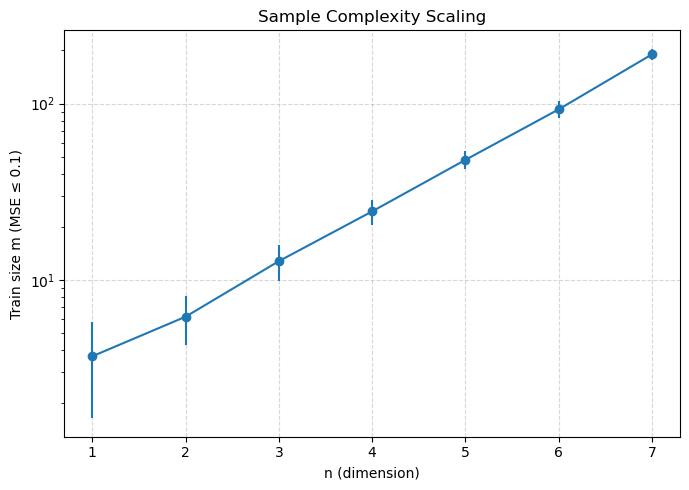

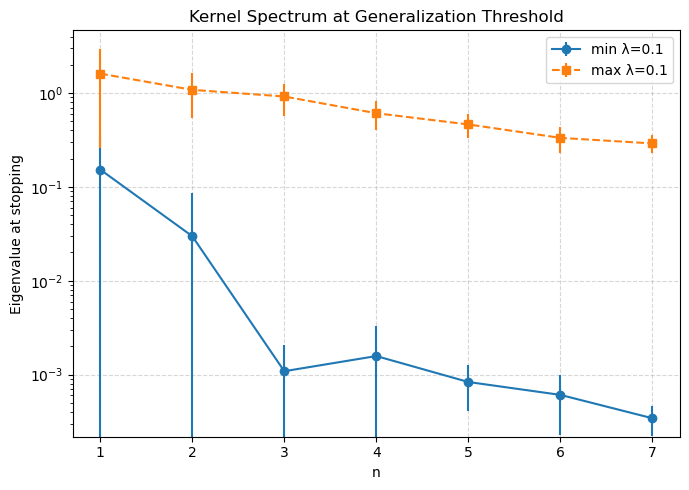

In [3]:
run_all_plots()

In [4]:
def plot_sample_complexity_by_bias():
    for tb in TRAIN_BIAS:
        plt.figure(figsize=(7,5))

        for lam in LAMBDAS:
            means = []
            stds = []
            ns = []

            for n in N_VALUES:
                key = (n, lam, tb, tb)  # matched train/test bias
                if key in all_results:
                    means.append(all_results[key]["required_mean"])
                    stds.append(all_results[key]["required_std"])
                    ns.append(n)

            plt.errorbar(
                ns, means, yerr=stds,
                marker="o", capsize=4,
                label=f"λ={lam}"
            )

        # plt.yscale("log")
        plt.xlabel("n (dimension)")
        plt.ylabel("Train size m (MSE ≤ 0.1)")
        plt.title(f"Sample Complexity")
        plt.grid(True, ls="--", alpha=0.5)
        # plt.legend()
        plt.tight_layout()
        plt.show()

In [5]:
def plot_sample_complexity_by_lambda():
    for lam in LAMBDAS:
        plt.figure(figsize=(7,5))

        for tb in TRAIN_BIAS:
            means = []
            stds = []
            ns = []

            for n in N_VALUES:
                key = (n, lam, tb, tb)
                if key in all_results:
                    means.append(all_results[key]["required_mean"])
                    stds.append(all_results[key]["required_std"])
                    ns.append(n)

            plt.errorbar(
                ns, means, yerr=stds,
                marker="o", capsize=4,
                label=f"bias={tb}"
            )

        # plt.yscale("log")
        plt.xlabel("n (dimension)")
        plt.ylabel("Train size m (MSE ≤ 0.1)")
        plt.title(f"Sample Complexity (λ = {lam})")
        plt.grid(True, ls="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

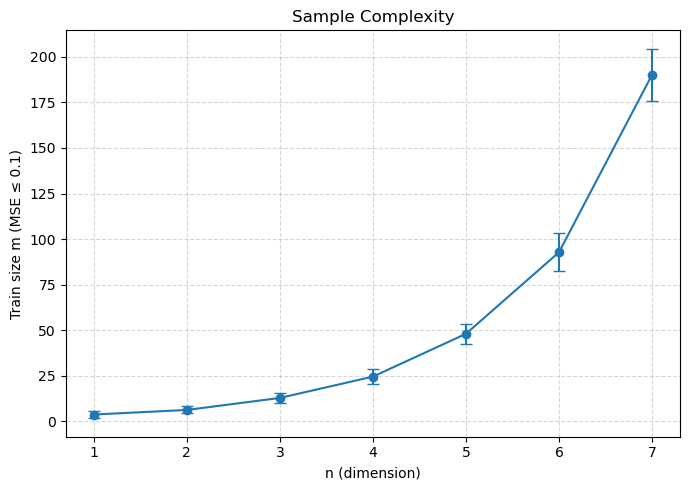

In [6]:
plot_sample_complexity_by_bias()
# plot_sample_complexity_by_lambda()

In [7]:
def plot_sample_complexity_by_bias_theory():
    for tb in TRAIN_BIAS:
        plt.figure(figsize=(8,5))

        for lam in LAMBDAS:
            means = []
            stds = []
            theory_vals = []
            ns = []

            for n in N_VALUES:
                key = (n, lam, tb, tb)

                if key in all_results:
                    res = all_results[key]

                    Nreq = res["required_mean"]
                    Nstd = res["required_std"]
                    sigma_min = res["eig_stop_min_mean"]

                    if np.isnan(Nreq) or np.isnan(sigma_min) or Nreq <= 0:
                        continue

                    # empirical
                    means.append(Nreq)
                    stds.append(Nstd)
                    ns.append(n)

                    # theory quantity
                    val = lam**2 / (sigma_min + lam)**2 + 4/(lam * Nreq)
                    # val = (16/(0.001*sigma_min**2))**(1/3)
                    theory_vals.append(val)

            # empirical complexity
            # plt.errorbar(
            #     ns, means, yerr=stds,
            #     marker="o", capsize=4,
            #     label=f"Empirical λ={lam}"
            # )

            # theory curve (secondary scale behavior)
            plt.plot(
                ns, theory_vals,
                marker="s",
                linestyle="--",
                label=f"Theory λ={lam}"
            )

        plt.xlabel("n (dimension)")
        plt.ylabel("Test Error")
        plt.title(f"Sample Complexity + Bound Term (bias={tb})")
        plt.grid(True, ls="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [8]:
# plot_sample_complexity_by_bias_theory()

In [9]:
def plot_sample_complexity_by_bias2():
    for tb in TRAIN_BIAS:
        plt.figure(figsize=(7,5))

        for lam in LAMBDAS:
            means = []
            stds = []
            ns = []
            worst = []
            for n in N_VALUES:
                key = (n, lam, tb, tb)  # matched train/test bias
                if key in all_results:
                    means.append(all_results[key]["required_mean"])
                    stds.append(all_results[key]["required_std"])
                    worst.append(all_results[key]["worst_required"])
                    ns.append(n)

            plt.plot(
                ns, means,
                marker="o",
                label=f"λ={lam}"
            )
            
        # plt.yscale("log")
        plt.xlabel("n (dimension)")
        plt.ylabel("Train size (MSE ≤ 0.1)")
        plt.title(f"Sample Complexity (bias = {tb})")
        plt.grid(True, ls="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [10]:
def plot_sample_complexity_by_lambda2():
    for lam in LAMBDAS:
        plt.figure(figsize=(7,5))

        for tb in TRAIN_BIAS:
            means = []
            stds = []
            ns = []
            for n in N_VALUES:
                key = (n, lam, tb, tb)
                if key in all_results:
                    means.append(all_results[key]["required_mean"])
                    stds.append(all_results[key]["required_std"])
                    ns.append(n)

            plt.plot(
                ns, means,
                marker="o",
                label=f"bias={tb}"
            )

        # plt.yscale("log")
        plt.xlabel("n (dimension)")
        plt.ylabel("Train size (MSE ≤ 0.1)")
        plt.title(f"Sample Complexity (λ = {lam})")
        plt.grid(True, ls="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [11]:
def plot_sample_complexity_by_worstbias2():
    for tb in TRAIN_BIAS:
        plt.figure(figsize=(7,5))

        for lam in LAMBDAS:
            means = []
            stds = []
            ns = []
            worst = []
            for n in N_VALUES:
                key = (n, lam, tb, tb)  # matched train/test bias
                if key in all_results:
                    means.append(all_results[key]["required_mean"])
                    stds.append(all_results[key]["required_std"])
                    worst.append(all_results[key]["worst_required"])
                    ns.append(n)

            plt.plot(
                ns, worst,
                marker="o",
                label=f"λ={lam}"
            )
            
        # plt.yscale("log")
        plt.xlabel("n (dimension)")
        plt.ylabel("Train size (MSE ≤ 0.1)")
        plt.title(f"Sample Complexity(Worst case)")
        plt.grid(True, ls="--", alpha=0.5)
        # plt.legend()
        plt.tight_layout()
        plt.show()

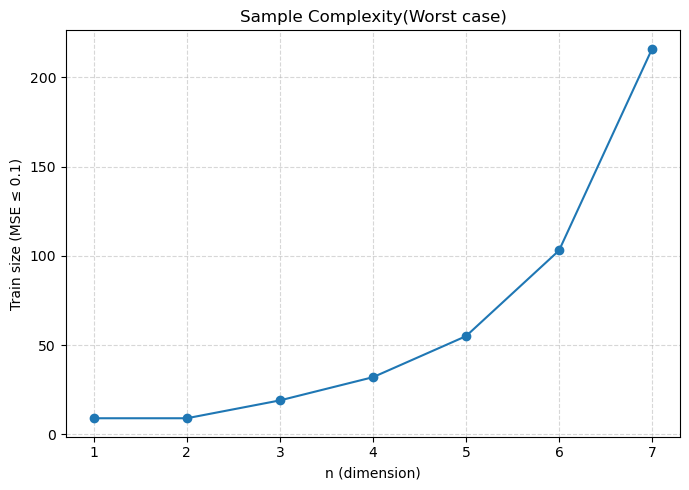

In [12]:
# plot_sample_complexity_by_bias2()
# plot_sample_complexity_by_lambda2()
plot_sample_complexity_by_worstbias2()

In [13]:
# def plot_train_test_bounds(n, lam, tb, vb):
#     """
#     For fixed (n, lambda, train_bias, test_bias), plot on same figure:

#     1) Train MSE
#     2) Test MSE
#     3) y = 0.1 threshold
#     4) (lam^2 ||y||^2)/(m (lam + sigma_min)^2)
#     5) (lam^2 ||y||^2)/(m (lam + sigma_max)^2)
#     6) ||y||^2 / m
#     7) (lam^2 ||y||^2)/(m (lam + m)^2)

#     Uses averages over seeds.
#     """

#     res = all_results[(n, lam, tb, vb)]

#     m_vals = np.array(TRAIN_SIZES, dtype=float)

#     train_mean = res["train_mean"]
#     test_mean  = res["test_mean"]

#     # Mean min/max eigenvalues over seeds
#     sigma_min = np.array(res["min_eig_mean"], dtype=float)
#     sigma_max = np.array(res["max_eig_mean"], dtype=float)

#     # Compute ||y||^2 averaged over seeds for each prefix length m
#     # Y_train_all = list of length (#seeds), each item full train labels
#     y_norm_sq = []

#     for mi, m in enumerate(TRAIN_SIZES):
#         vals = []
#         for yfull in res["Y_train_all"]:
#             y_prefix = np.asarray(yfull[:m], dtype=float)
#             vals.append(np.sum(y_prefix**2))
#         y_norm_sq.append(np.mean(vals))

#     y_norm_sq = np.array(y_norm_sq, dtype=float)

#     eps = 1e-14

#     # Curves
#     bound_min = (lam**2 * y_norm_sq) / (
#         m_vals * (lam + sigma_min + eps)**2
#     )

#     bound_max = (lam**2 * y_norm_sq) / (
#         m_vals * (lam + sigma_max + eps)**2
#     )

#     bound_plain = y_norm_sq / m_vals

#     bound_m = (lam**2 * y_norm_sq) / (
#         m_vals * (lam + m_vals)**2
#     )

#     # Plot
#     plt.figure(figsize=(9,6))

#     plt.plot(m_vals, train_mean, lw=2, label="Train MSE")
#     plt.plot(m_vals, test_mean, lw=2, label="Test MSE")

#     plt.axhline(
#         MSE_THRESHOLD,
#         linestyle="--",
#         linewidth=2,
#         label=f"Threshold = {MSE_THRESHOLD}"
#     )

#     plt.plot(m_vals, bound_min, "--", lw=2,
#              label=r"$\frac{\lambda^2\|y\|^2}{m(\lambda+\sigma_{\min})^2}$")

#     plt.plot(m_vals, bound_max, "--", lw=2,
#              label=r"$\frac{\lambda^2\|y\|^2}{m(\lambda+\sigma_{\max})^2}$")

#     plt.plot(m_vals, bound_plain, ":", lw=2,
#              label=r"$\frac{\|y\|^2}{m}$")

#     plt.plot(m_vals, bound_m, "-.", lw=2,
#              label=r"$\frac{\lambda^2\|y\|^2}{m(\lambda+m)^2}$")

#     plt.yscale("log")
#     plt.xlabel("Train size m")
#     plt.ylabel("MSE / Bound")
#     plt.title(f"n={n}, λ={lam}, train_bias={tb}, test_bias={vb}")
#     plt.grid(True, ls="--", alpha=0.4)
#     plt.legend(fontsize=9)
#     plt.tight_layout()
#     plt.show()

In [14]:
# =====================================================
# DEFINE LAMBDA SCHEDULE IN ONE PLACE
# Change ONLY this function later if desired:
#   return lam / np.sqrt(m)   -> current choice
#   return lam / m            -> alternative
#   return lam                -> fixed lambda
#   return lam / (m**0.75)    -> another option
# =====================================================
def lambda_schedule(lam, m):
    m = np.asarray(m, dtype=float)
    return lam /np.sqrt(m)


def plot_train_test_bounds(n, lam, tb, vb):
    """
    For fixed (n, lambda, train_bias, test_bias), plot:

    1) Train MSE
    2) Test MSE
    3) threshold
    4) (λ(m)^2 ||y||^2)/(m (λ(m)+σ_min)^2)
    5) (λ(m)^2 ||y||^2)/(m (λ(m)+σ_max)^2)
    6) ||y||^2 / m
    7) (λ(m)^2 ||y||^2)/(m (λ(m)+m)^2)

    where λ(m) is controlled ONLY by lambda_schedule().
    """

    res = all_results[(n, lam, tb, vb)]

    m_vals = np.array(TRAIN_SIZES, dtype=float)

    train_mean = res["train_mean"]
    test_mean  = res["test_mean"]

    sigma_min = np.array(res["min_eig_mean"], dtype=float)
    sigma_max = np.array(res["max_eig_mean"], dtype=float)

    # ==========================================
    # Compute ||y||^2 averaged over seeds
    # ==========================================
    y_norm_sq = []

    for m in TRAIN_SIZES:
        vals = []
        for yfull in res["Y_train_all"]:
            y_prefix = np.asarray(yfull[:m], dtype=float)
            vals.append(np.sum(y_prefix**2))
        y_norm_sq.append(np.mean(vals))

    y_norm_sq = np.array(y_norm_sq, dtype=float)

    # ==========================================
    # Lambda depends on train size m
    # ==========================================
    lam_vals = lambda_schedule(lam, m_vals)

    eps = 1e-14

    # ==========================================
    # Bounds
    # ==========================================
    bound_min = (lam_vals**2 * y_norm_sq) / (
        m_vals * (lam_vals + sigma_min + eps)**2
    )

    bound_max = (lam_vals**2 * y_norm_sq) / (
        m_vals * (lam_vals + sigma_max + eps)**2
    )

    bound_plain = y_norm_sq / m_vals

    bound_m = (lam_vals**2 * y_norm_sq) / (
        m_vals * (lam_vals + m_vals)**2
    )

    # ==========================================
    # Plot
    # ==========================================
    plt.figure(figsize=(9,6))

    plt.plot(m_vals, train_mean, lw=2, label="Train MSE")
    plt.plot(m_vals, test_mean, lw=2, label="Test MSE")

    plt.axhline(
        MSE_THRESHOLD,
        linestyle="--",
        linewidth=2,
        label=f"Threshold = {MSE_THRESHOLD}"
    )

    plt.plot(
        m_vals, bound_min, "--", lw=2,
        label=r"$\frac{\lambda(m)^2\|y\|^2}{m(\lambda(m)+\sigma_{\min})^2}$"
    )

    plt.plot(
        m_vals, bound_max, "--", lw=2,
        label=r"$\frac{\lambda(m)^2\|y\|^2}{m(\lambda(m)+\sigma_{\max})^2}$"
    )

    # plt.plot(
    #     m_vals, bound_plain, ":", lw=2,
    #     label=r"$\frac{\|y\|^2}{m}$"
    # )

    # plt.plot(
    #     m_vals, bound_m, "-.", lw=2,
    #     label=r"$\frac{\lambda(m)^2\|y\|^2}{m(\lambda(m)+m)^2}$"
    # )

    plt.yscale("log")
    plt.xlabel("Train size m")
    plt.ylabel("MSE")
    plt.title(f"Train and Test MSE (n={n})")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

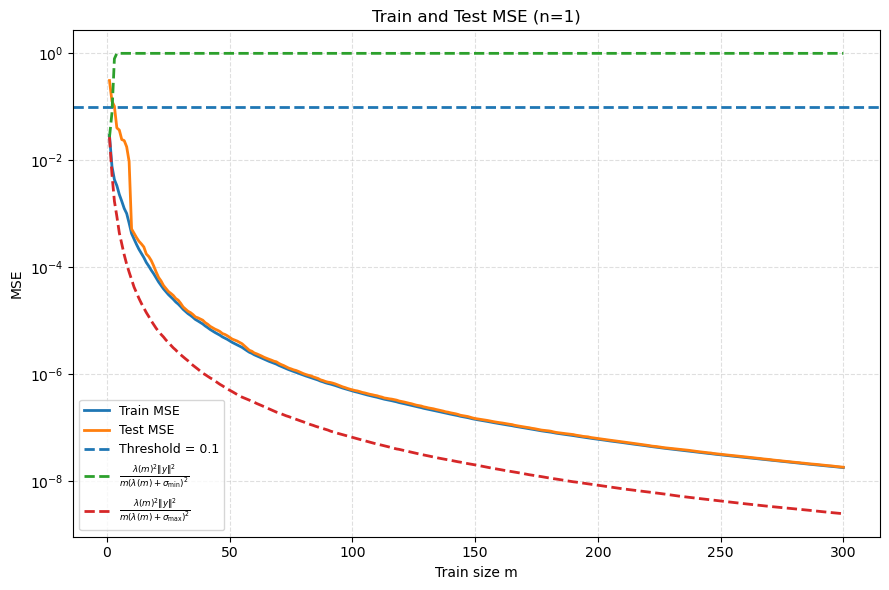

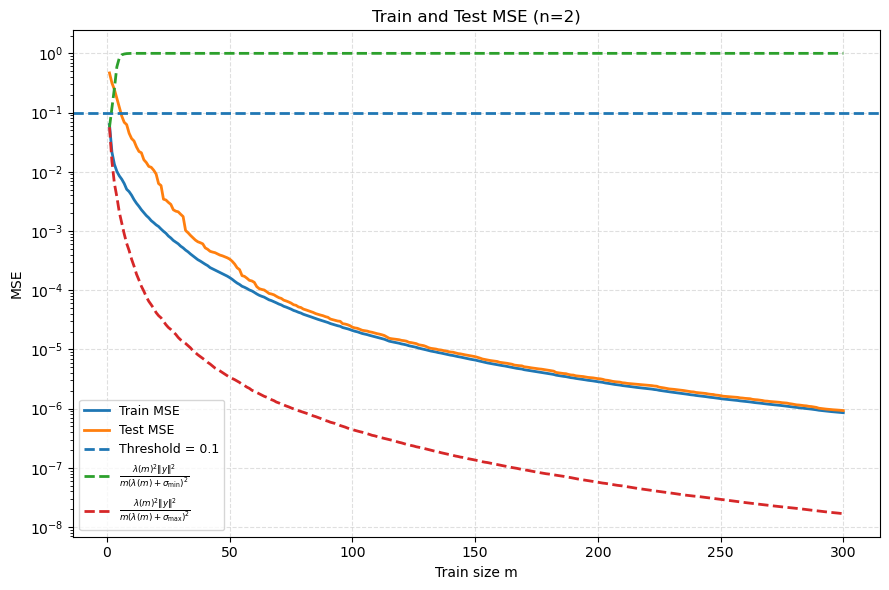

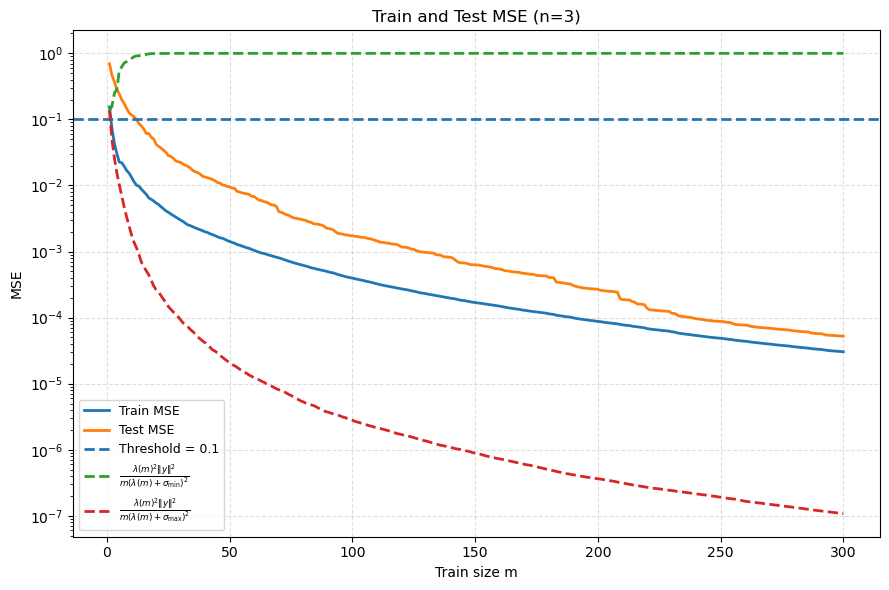

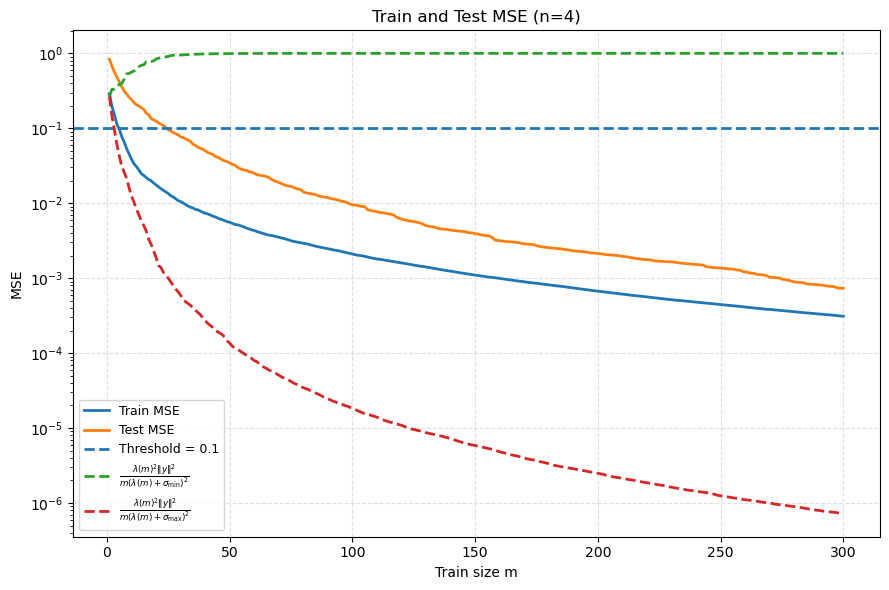

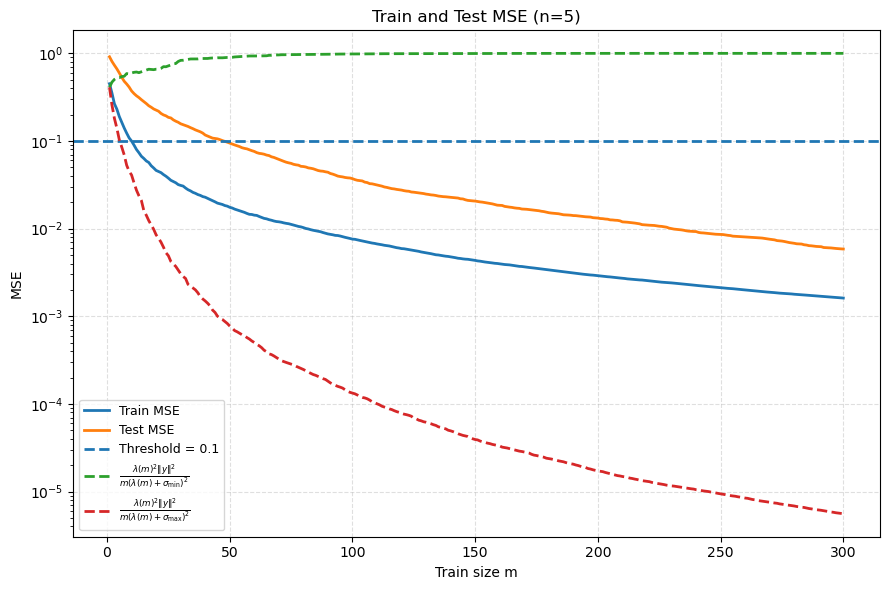

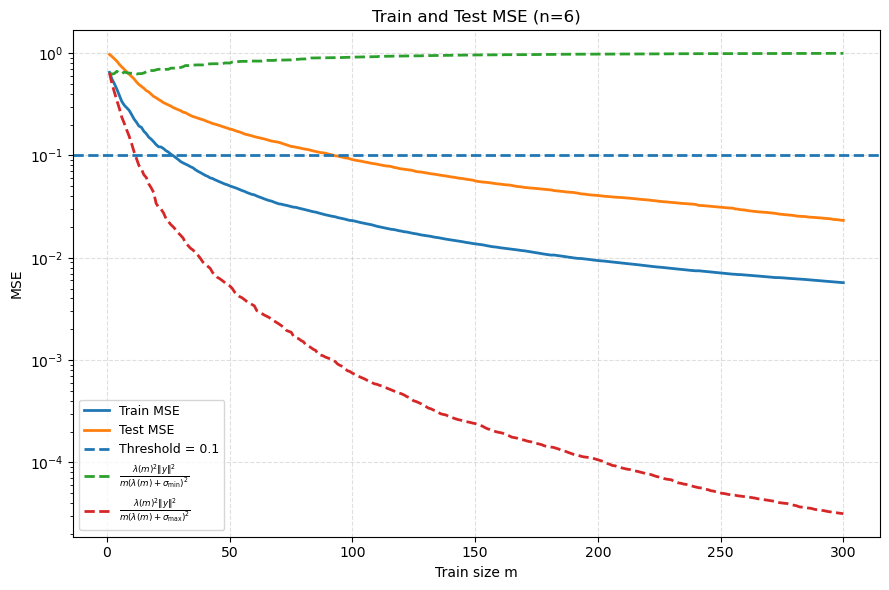

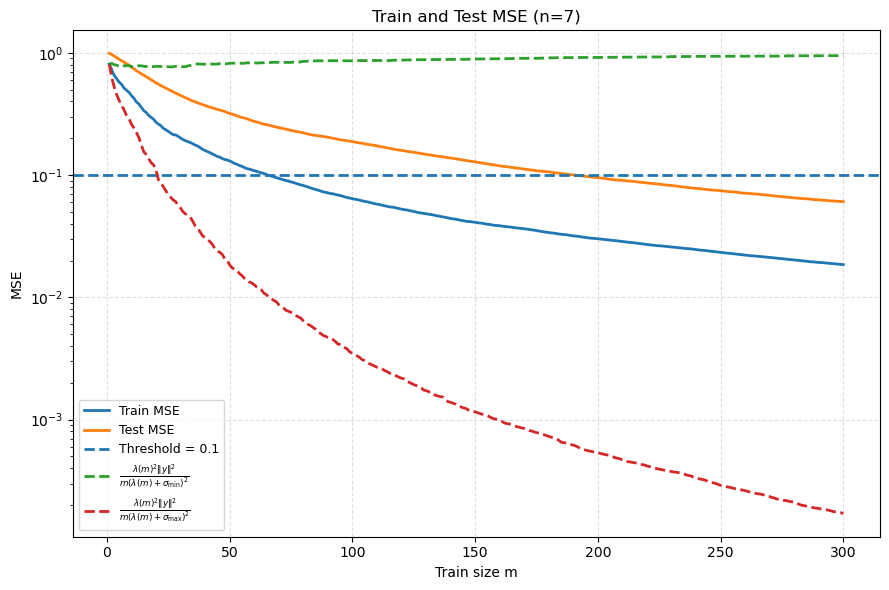

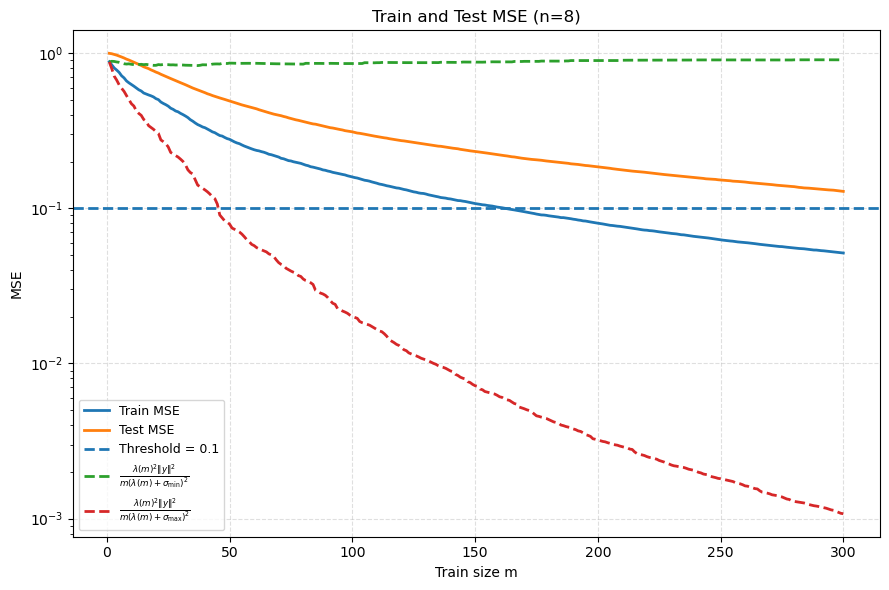

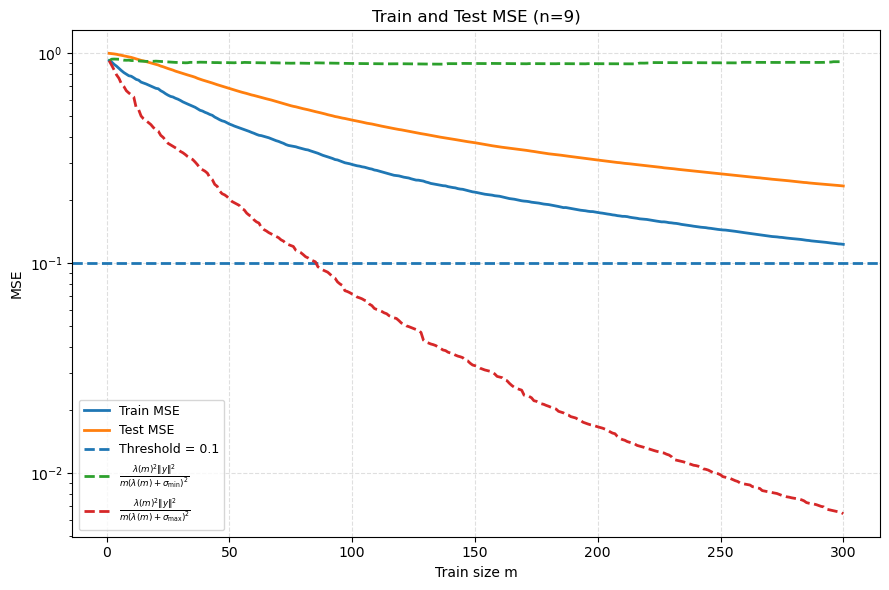

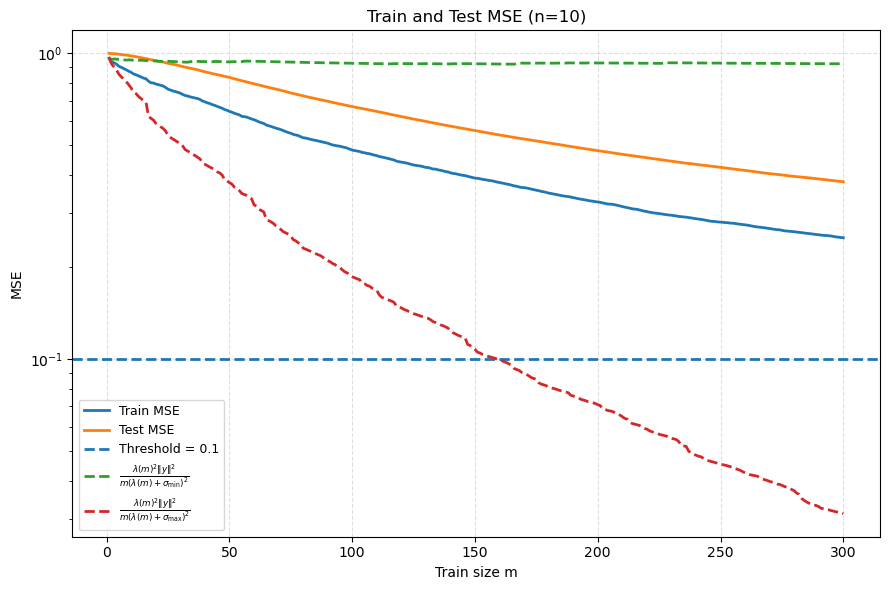

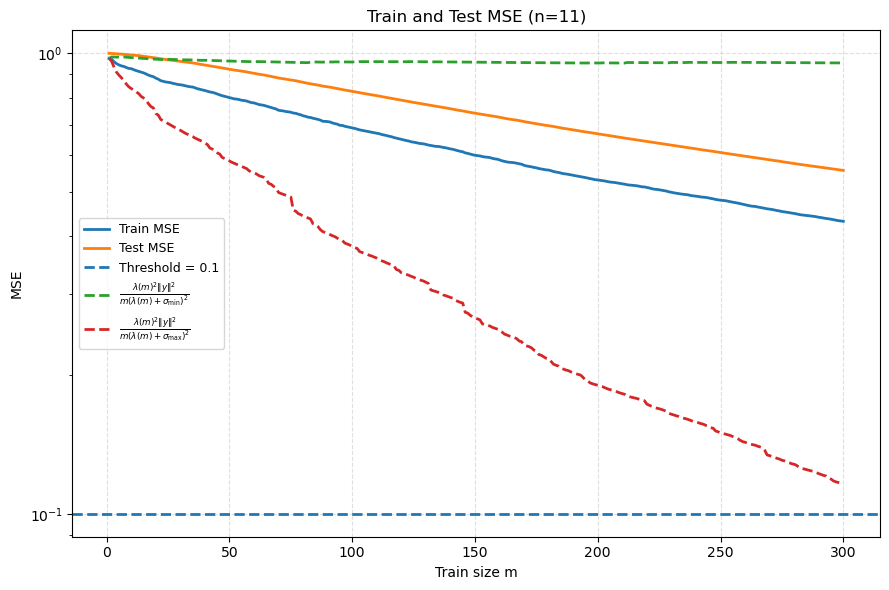

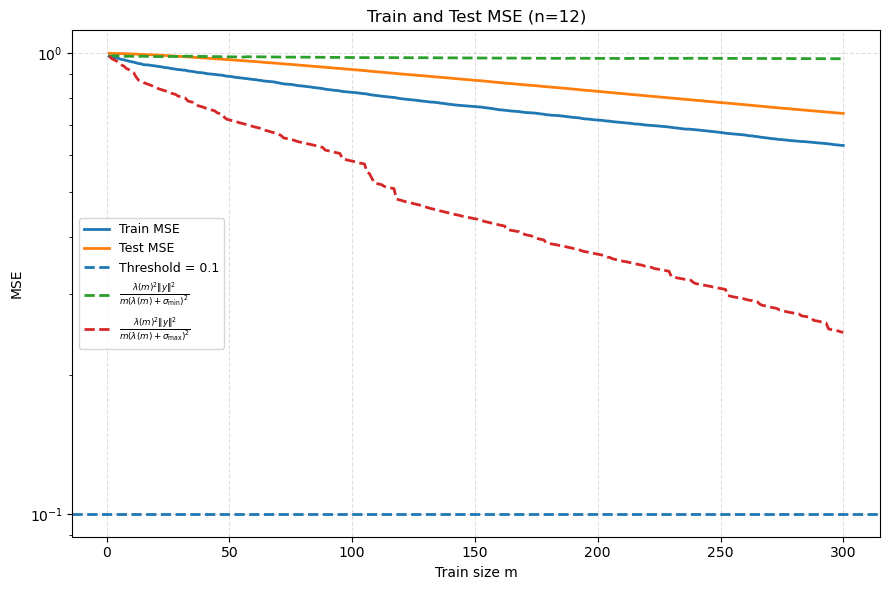

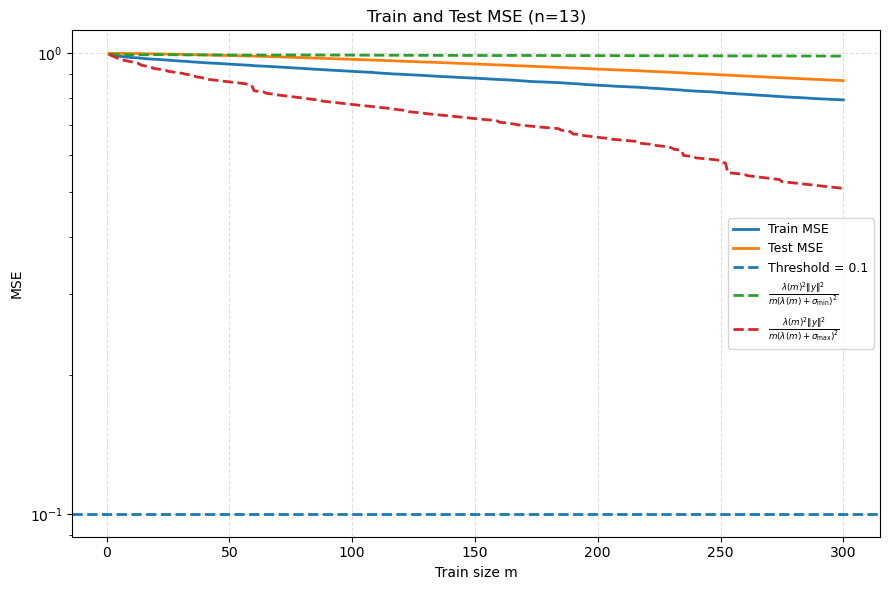

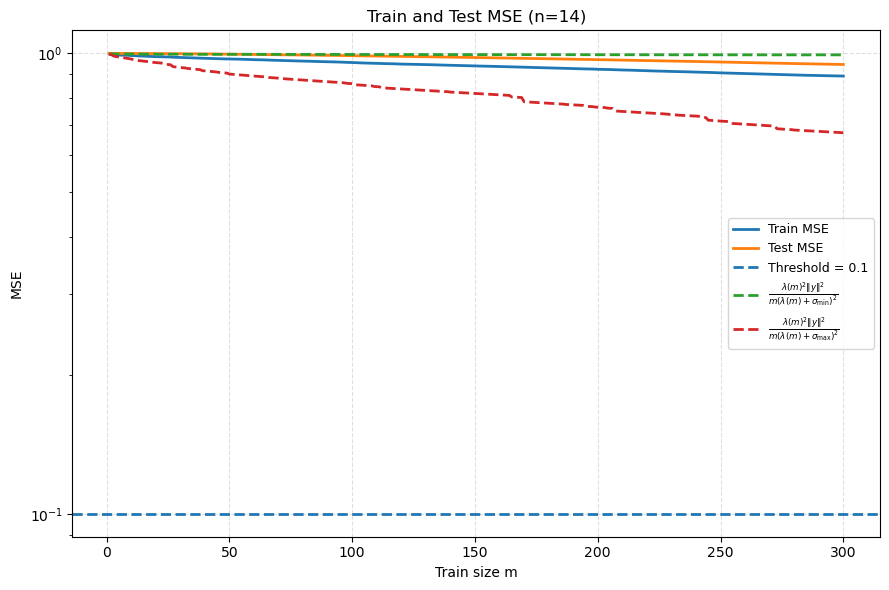

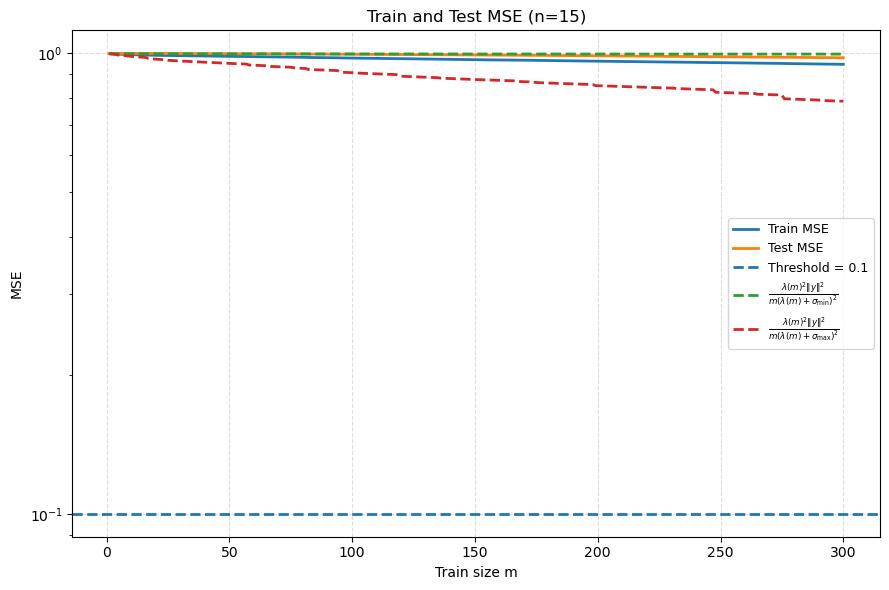

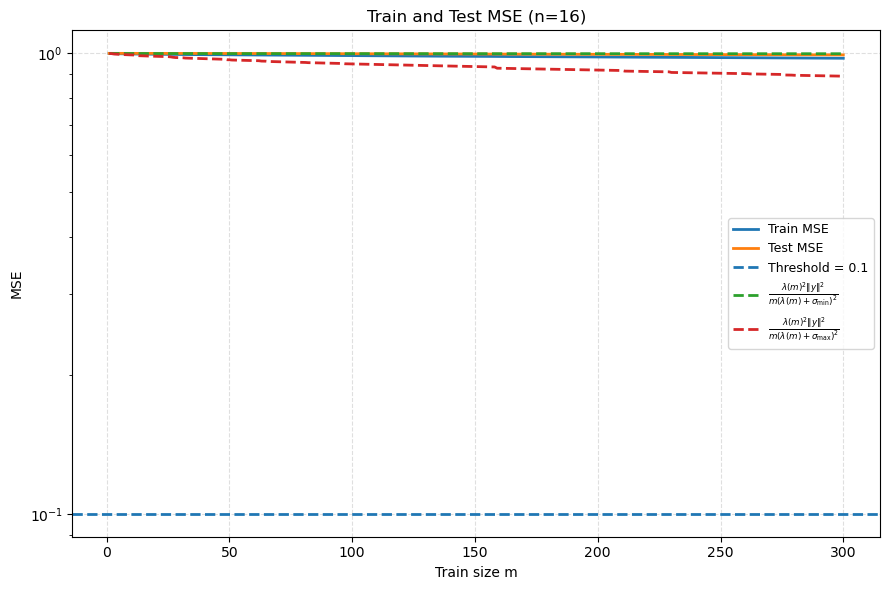

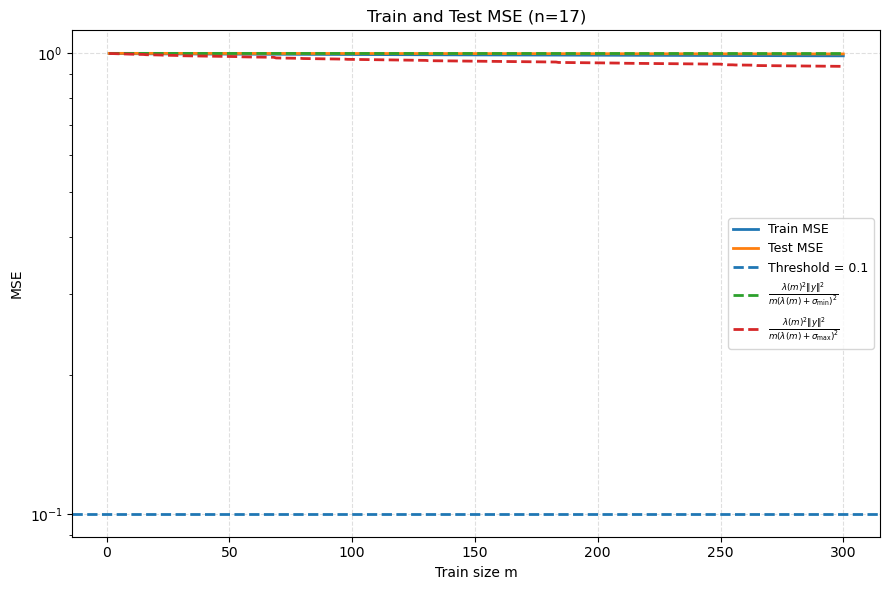

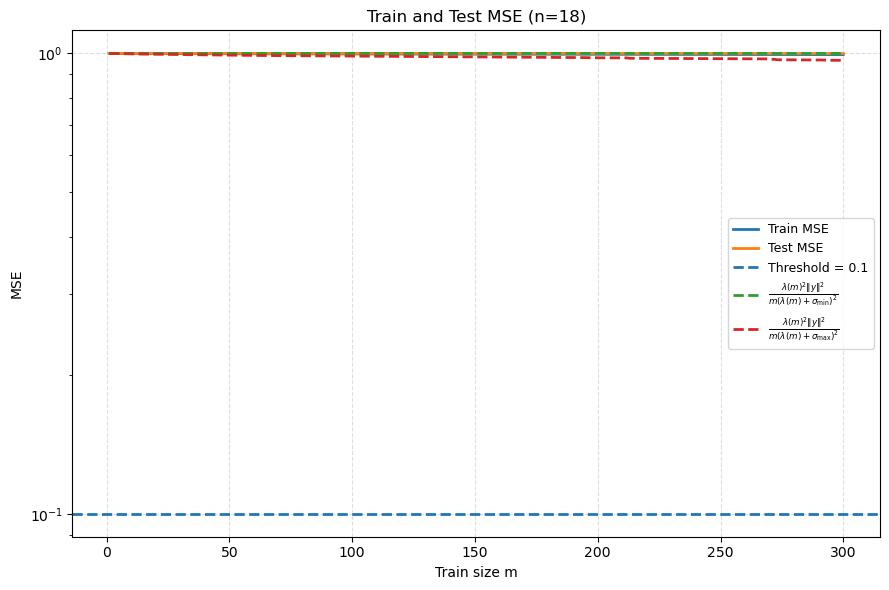

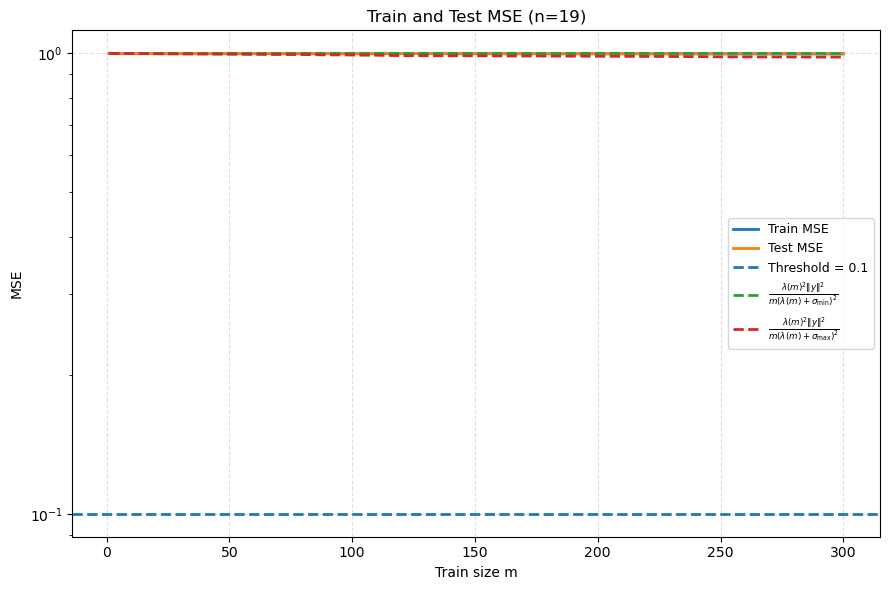

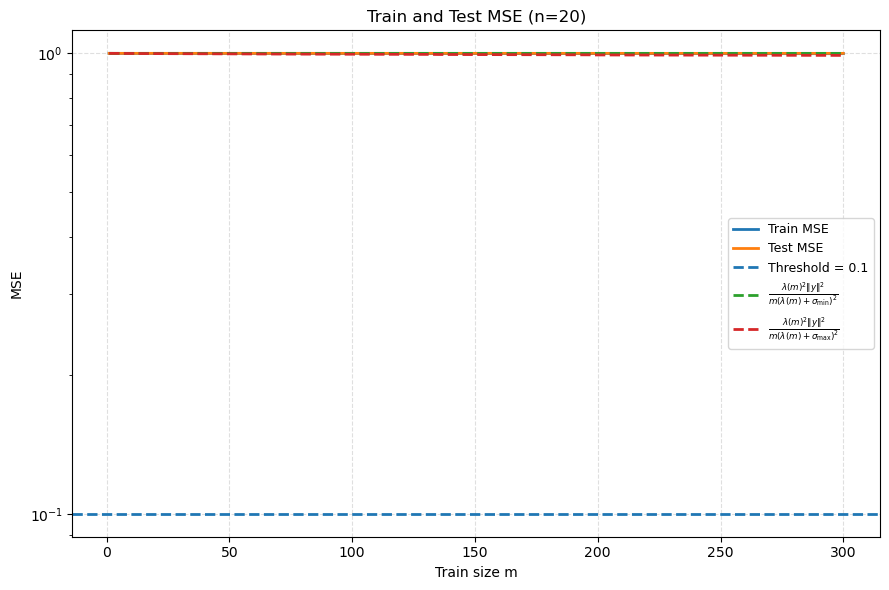

In [15]:
# Run for all n and lambda combinations
for n in N_VALUES:
    for lam in LAMBDAS:
        for tb in TRAIN_BIAS:
            for vb in TEST_BIAS:
                plot_train_test_bounds(n, lam, tb, vb)

In [16]:
def plot_sigma_scaling(n, lam, tb, vb):
    res = all_results[(n, lam, tb, vb)]

    m_vals = np.array(TRAIN_SIZES, dtype=float)

    sigma_min = np.array(res["min_eig_mean"], dtype=float)
    sigma_max = np.array(res["max_eig_mean"], dtype=float)

    # Reference curves
    ref_min = m_vals * (0.0315 ** n)
    ref_max = m_vals * (0.3875 ** n)

    plt.figure(figsize=(9, 6))

    # Solid lines (with transparency + markers)
    # line_min, = plt.plot(
    #     m_vals,
    #     sigma_min,
    #     lw=2,
    #     alpha=0.75,
    #     marker="o",
    #     markersize=5,
    #     markevery=20,
    #     label=r"$\sigma_{\min}$"
    # )

    line_max, = plt.plot(
        m_vals,
        sigma_max,
        lw=2,
        alpha=0.75,
        marker="^",
        markersize=6,
        markevery=30,
        label=r"$\sigma_{\max}$"
    )

    # Dotted lines with matching colors
    # plt.plot(
    #     m_vals,
    #     ref_min,
    #     ":",
    #     lw=2,
    #     color=line_min.get_color(),
    #     label=rf"$m(0.0315)^{{{n}}}$"
    # )

    plt.plot(
        m_vals,
        ref_max,
        ":",
        lw=2,
        color=line_max.get_color(),
        label=rf"$m(0.3875)^{{{n}}}$"
    )

    plt.yscale("log")      # optional
    plt.xlabel("Train size m")
    plt.ylabel("Value")
    plt.title(f"Predicted vs Actual Eigenvalues (n={n})")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
    

In [17]:
def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

For n=1, R² = 0.9998
For n=2, R² = 0.9992
For n=3, R² = 0.9995
For n=4, R² = 0.9994
For n=5, R² = 0.9863
For n=6, R² = 0.9961
For n=7, R² = 0.9319


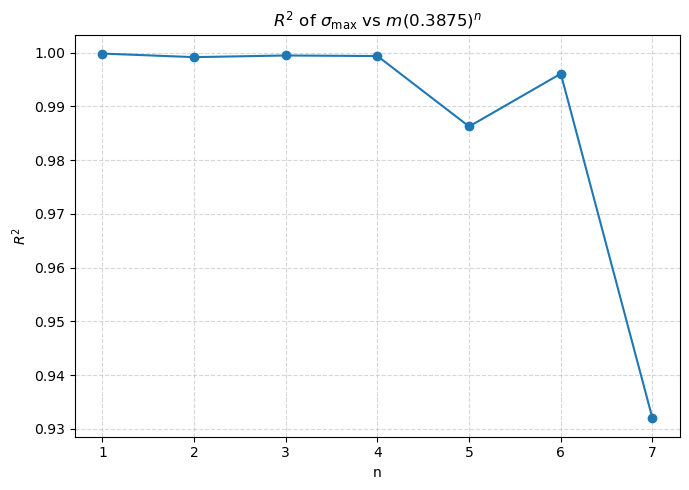

In [44]:
r2s = []
ns_plot = []

for n in range(1,8):
    res = all_results[(n, lam, tb, vb)]

    m_vals = np.array(TRAIN_SIZES, dtype=float)
    sigma_max = np.array(res["max_eig_mean"], dtype=float)

    ref_max = m_vals * (0.3875 ** n)

    mask = np.isfinite(sigma_max) & np.isfinite(ref_max)

    r2 = r2_score(
        sigma_max[mask],
        ref_max[mask]
    )

    r2s.append(r2)
    ns_plot.append(n)

    print(f"For n={n}, R² = {r2:.4f}")

plt.figure(figsize=(7,5))
plt.plot(ns_plot, r2s, marker="o")
plt.xlabel("n")
plt.ylabel(r"$R^2$")
plt.title(r"$R^2$ of $\sigma_{\max}$ vs $m(0.3875)^n$")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

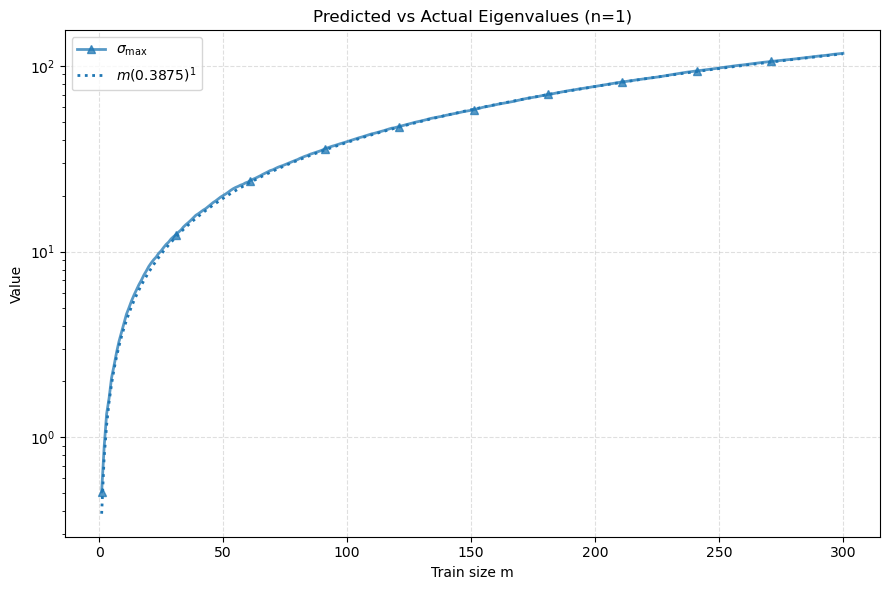

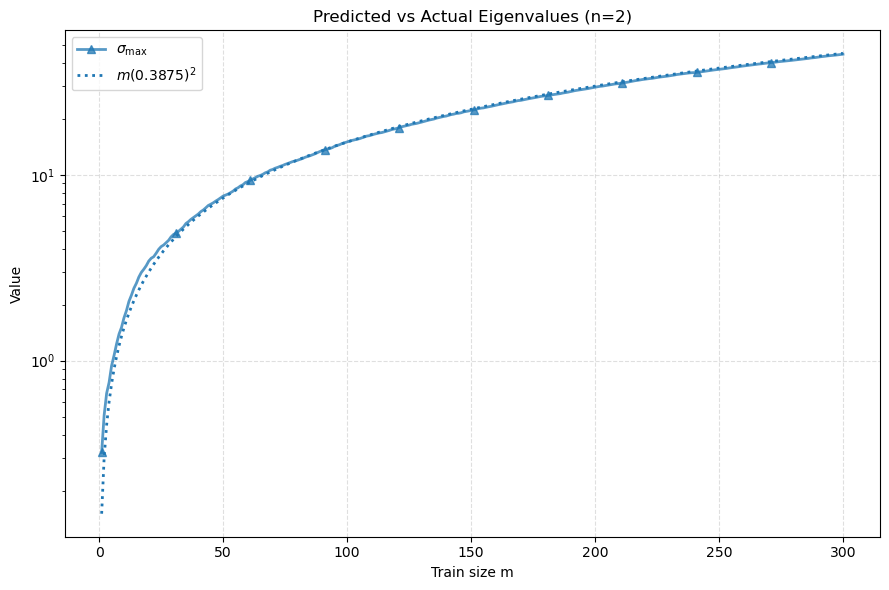

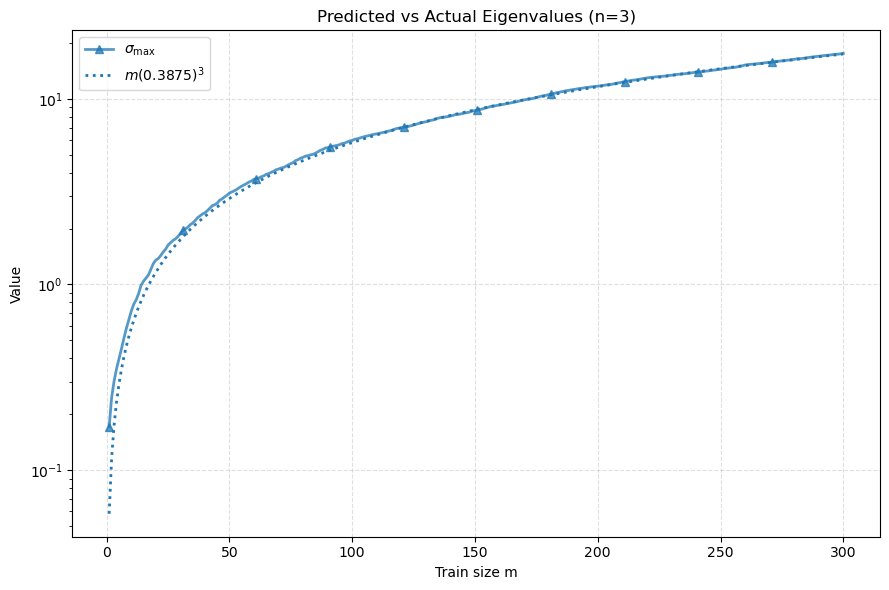

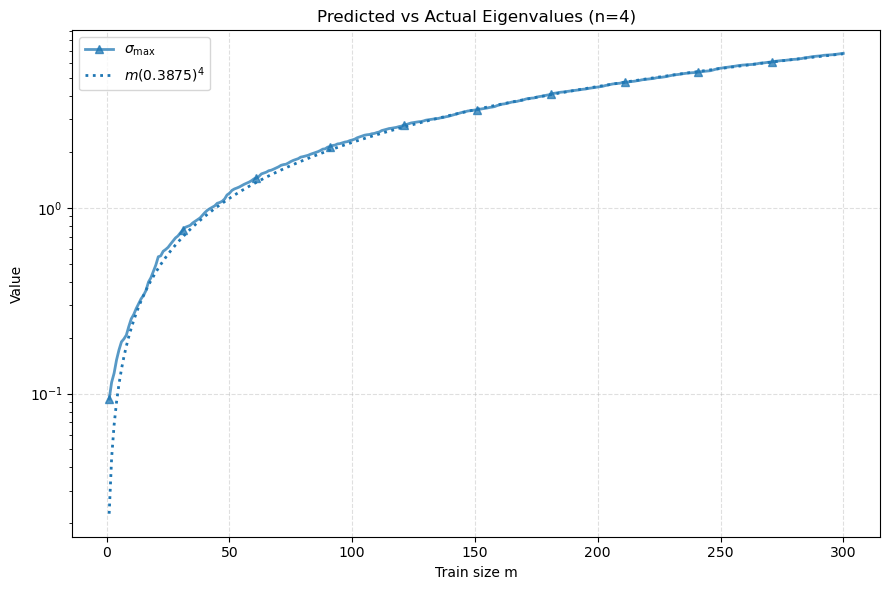

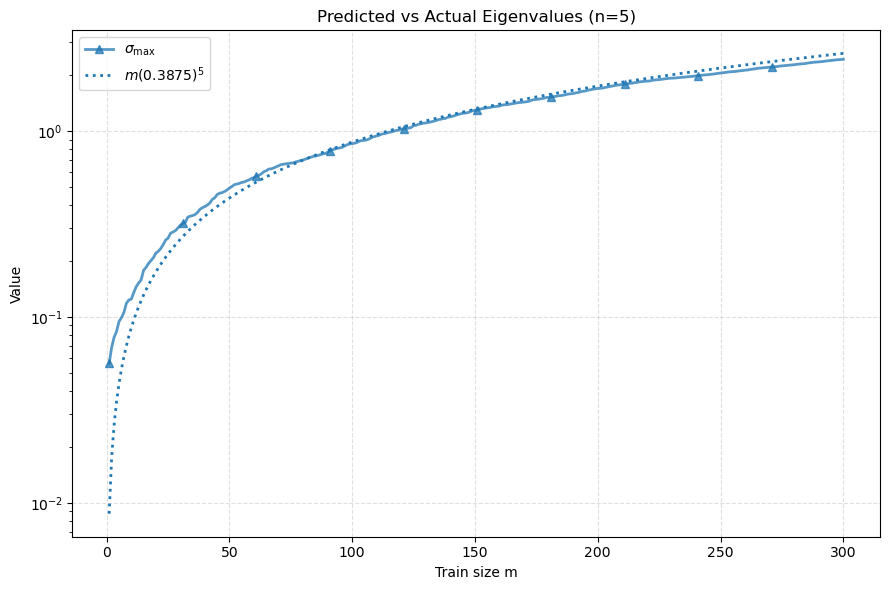

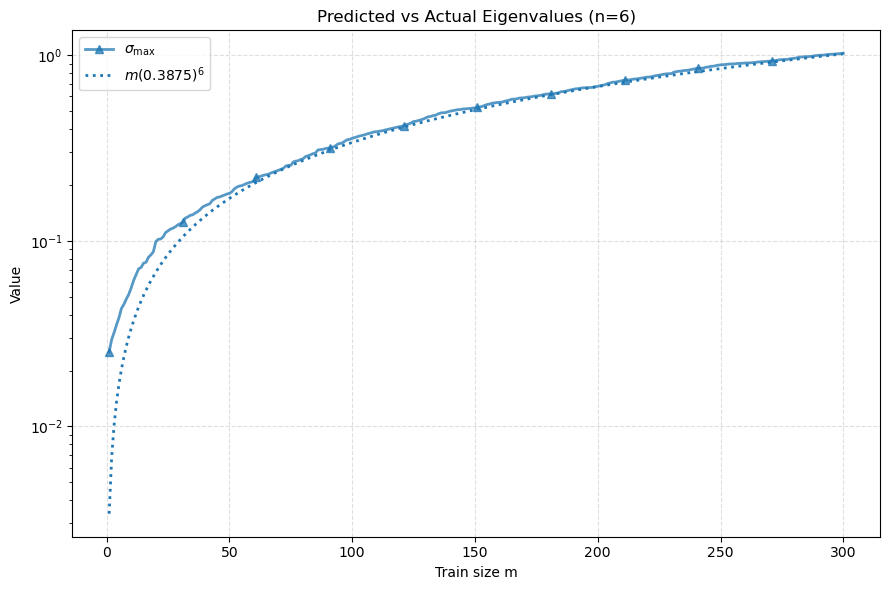

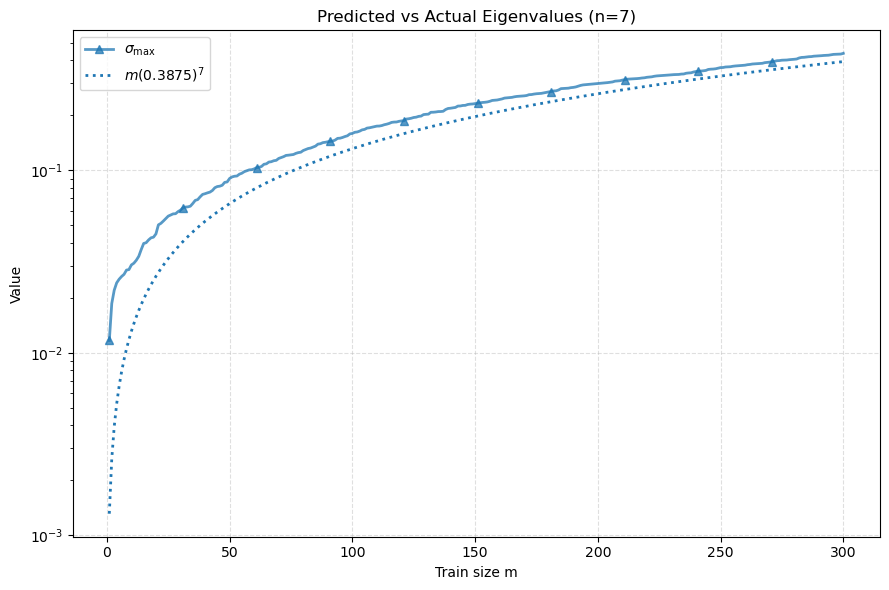

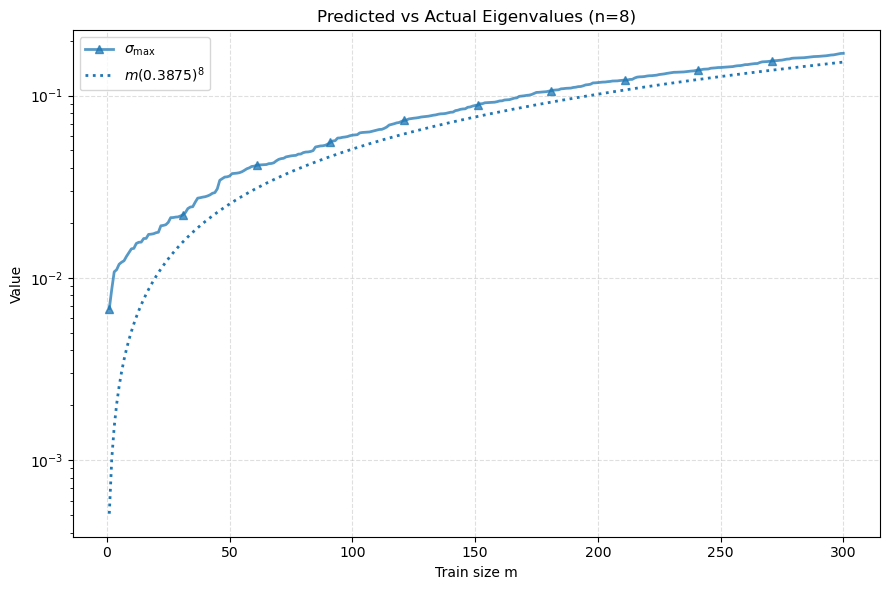

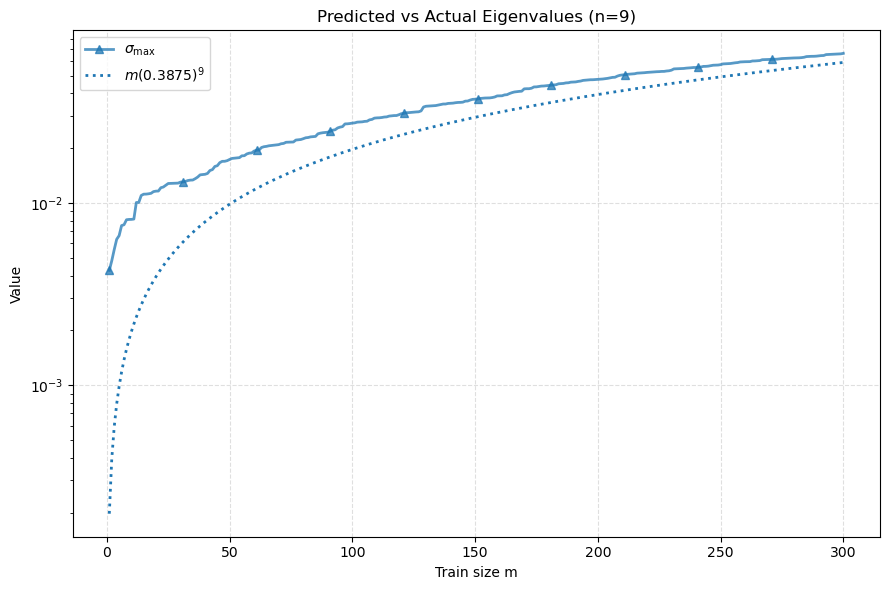

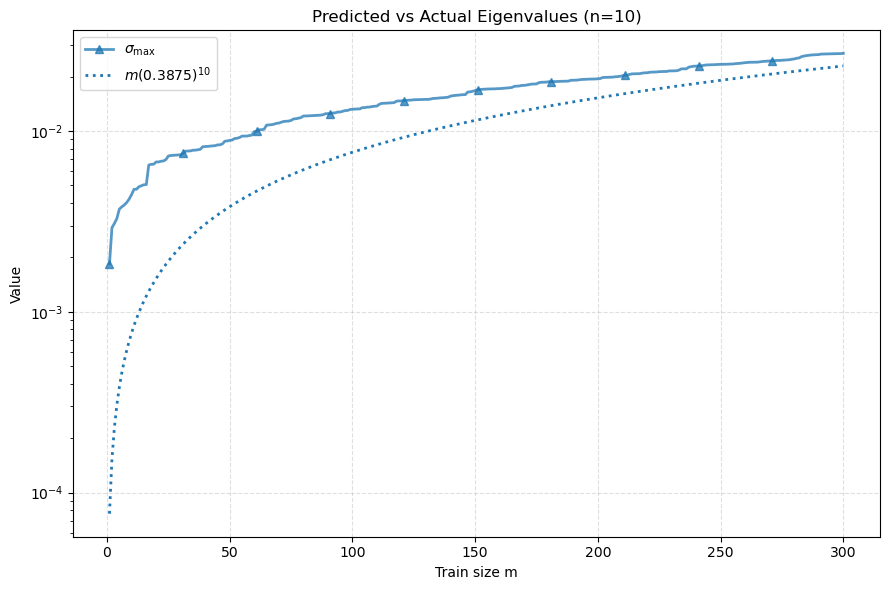

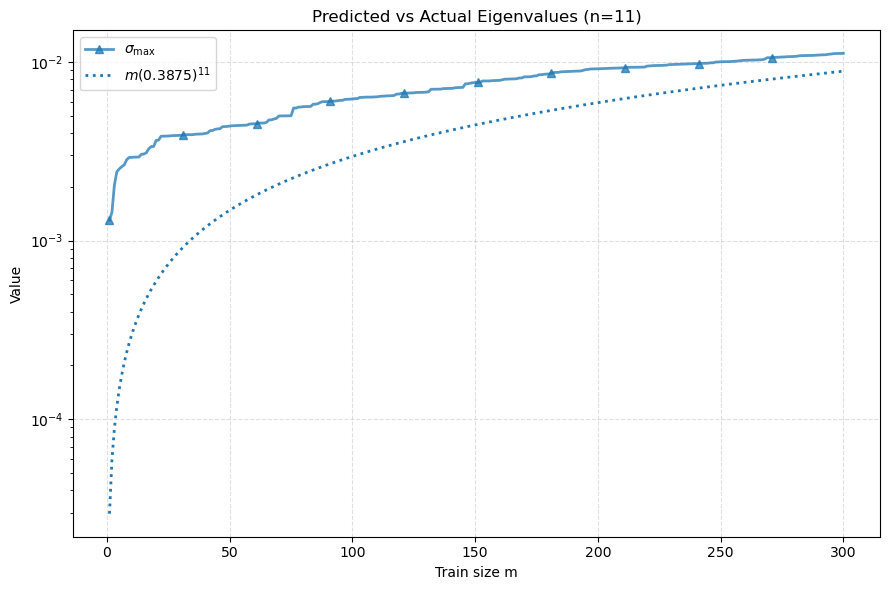

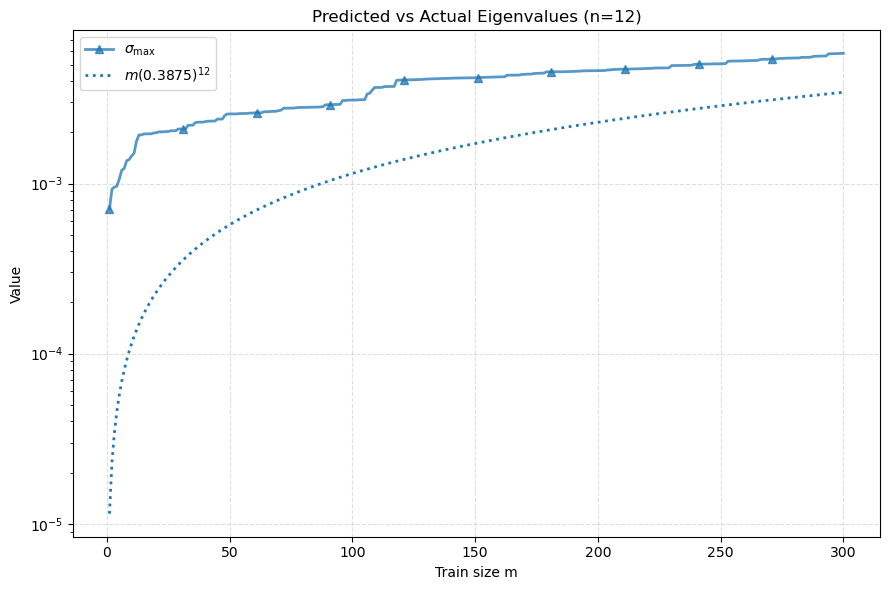

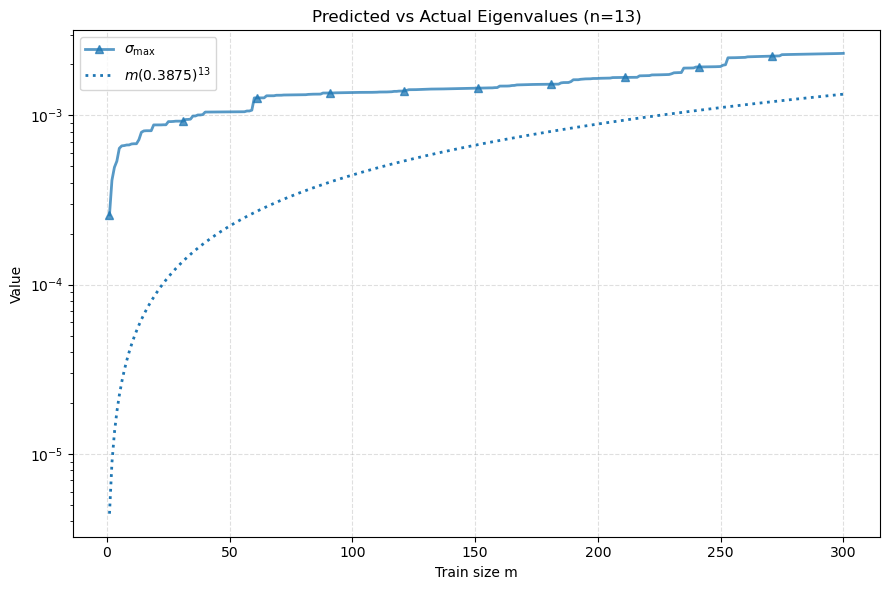

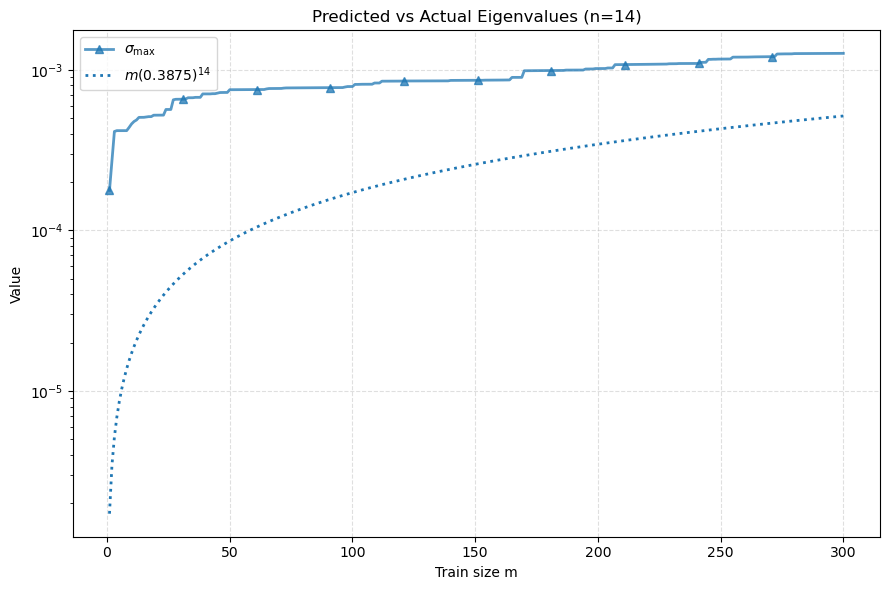

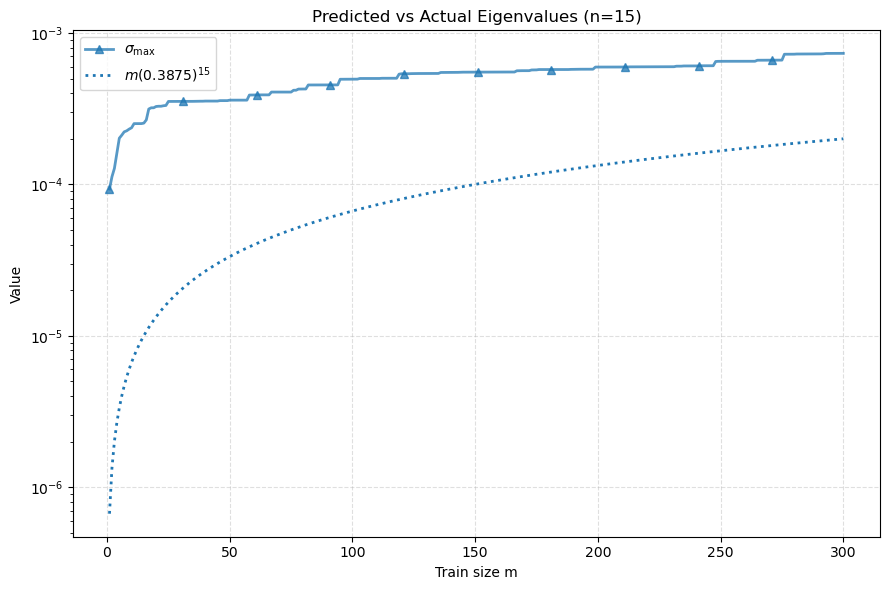

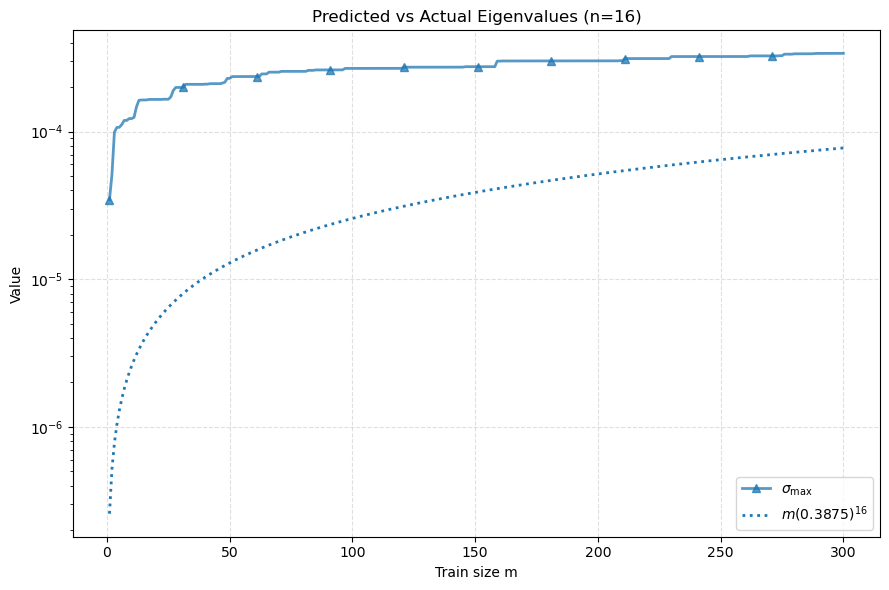

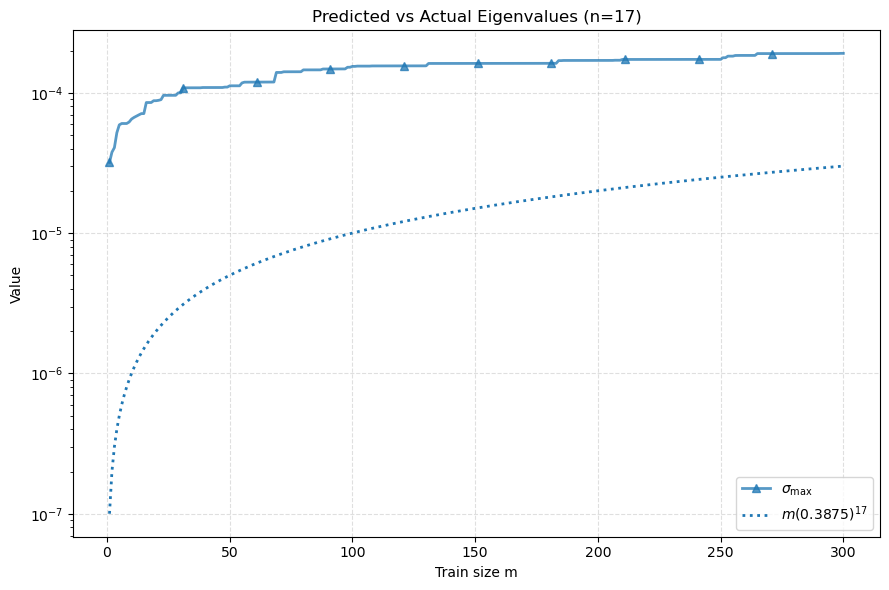

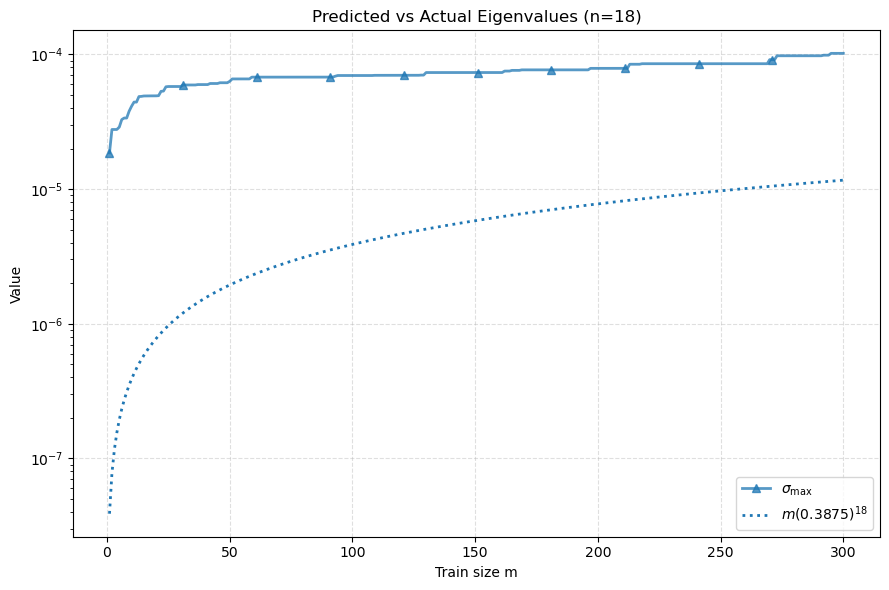

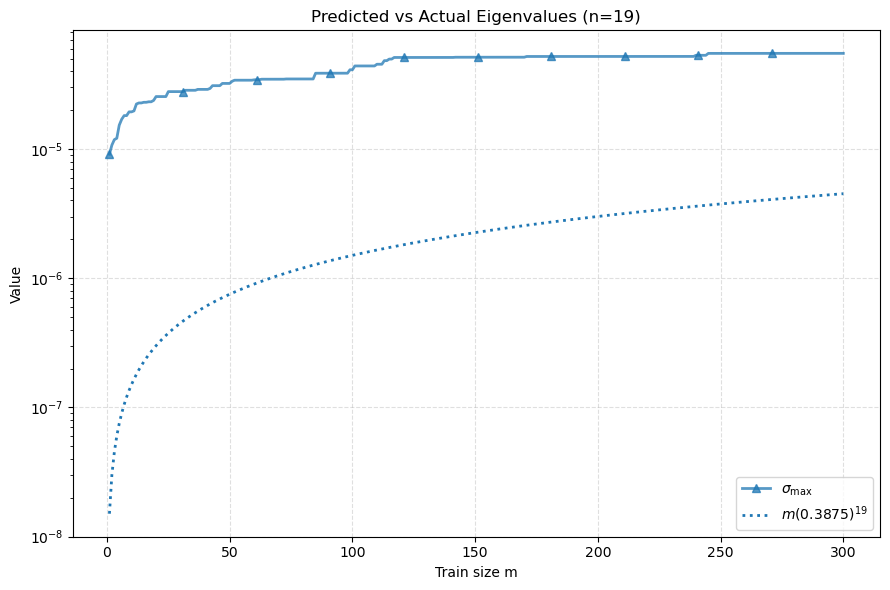

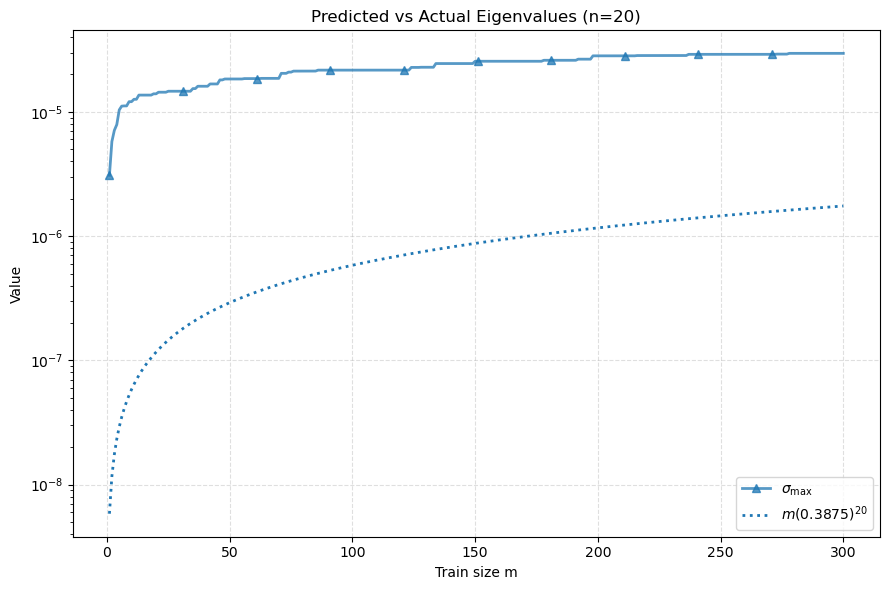

In [19]:
for n in N_VALUES:
    for lam in LAMBDAS:
        for tb in TRAIN_BIAS:
            for vb in TEST_BIAS:
                plot_sigma_scaling(n, lam, tb, vb)

In [20]:
def plot_diagonality(n, lam, tb, vb):
    res = all_results[(n, lam, tb, vb)]

    plt.figure(figsize=(8,5))
    plt.plot(TRAIN_SIZES, res["diag_ratio_mean"], label="mean offdiag / diag")
    plt.plot(TRAIN_SIZES, res["off_energy_mean"], label="offdiag Frobenius ratio")

    plt.yscale("log")
    plt.xlabel("Train size")
    plt.ylabel("Diagonality metric")
    plt.title(f"How diagonal is K? n={n}, λ={lam}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [21]:
# for n in N_VALUES:
#     for lam in LAMBDAS:
#         for tb in TRAIN_BIAS:
#             for vb in TEST_BIAS:
#                 plot_diagonality(n, lam, tb, vb)

In [22]:
def plot_diagonal_vs_n(m_idx=99):
    vals = []

    for n in N_VALUES:
        key=(n,LAMBDAS[0],TRAIN_BIAS[0],TEST_BIAS[0])
        vals.append(all_results[key]["diag_ratio_mean"][m_idx])

    plt.figure(figsize=(7,5))
    plt.plot(N_VALUES, vals, marker='o')
    plt.yscale("log")
    plt.xlabel("dimension n")
    plt.ylabel("offdiag/diag")
    plt.title("Kernel collapsing to diagonal")
    plt.grid(True)
    plt.show()

In [23]:
# plot_diagonal_vs_n()

In [24]:
import pickle

save_data = {
    "all_results": all_results,
    "N_VALUES": N_VALUES,
    "LAMBDAS": LAMBDAS,
    "TRAIN_BIAS": TRAIN_BIAS,
    "TEST_BIAS": TEST_BIAS,
    "TRAIN_SIZES": TRAIN_SIZES,
    "SEEDS": SEEDS,
    "MSE_THRESHOLD": MSE_THRESHOLD
}
filename = "results/thesis_alpha0_unbiased.pkl"
with open(filename, "wb") as f:
    pickle.dump(save_data, f)

print("Results saved to ", filename)

Results saved to  results/thesis_alpha0_unbiased.pkl


In [25]:
import numpy as np
from scipy.stats import linregress
from scipy.optimize import curve_fit

In [39]:

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


def fit_scaling(ns, ys, fit_points=3):
    ns = np.asarray(ns, dtype=float)
    ys = np.asarray(ys, dtype=float)

    # Remove NaNs
    mask = np.isfinite(ys)
    ns_all = ns[mask]
    ys_all = ys[mask]

    # First 5 points for fitting
    ns_fit = ns_all[:fit_points]
    ys_fit = ys_all[:fit_points]

    results = {}

    # -------------------------
    # Exponential: y = C * a^n
    # -------------------------
    exp_mask = ys_fit > 0
    r_exp = linregress(ns_fit[exp_mask], np.log(ys_fit[exp_mask]))

    C_exp = np.exp(r_exp.intercept)
    a_exp = np.exp(r_exp.slope)

    exp_pred_all = C_exp * a_exp ** ns_all

    results["exp_base"] = a_exp
    results["exp_C"] = C_exp
    results["exp_r2_full"] = r2_score(ys_all, exp_pred_all)

    # -------------------------
    # Polynomial (quadratic)
    # -------------------------
    poly_coeffs = np.polyfit(ns_fit, ys_fit, deg=2)

    poly_pred_all = np.polyval(poly_coeffs, ns_all)

    results["poly_coeffs"] = poly_coeffs
    results["poly_r2_full"] = r2_score(ys_all, poly_pred_all)

    return results

In [40]:
means = []
ns = []
for tb in TRAIN_BIAS: 
    for lam in LAMBDAS:  
        for n in N_VALUES: 
            key = (n, lam, tb, tb) # matched train/test bias 
            if key in all_results: 
                means.append(all_results[key]["required_mean"])
                ns.append(n)

In [41]:
res = fit_scaling(ns, means)

print("exp R²:", res["exp_r2_full"])
print("poly R²:", res["poly_r2_full"])
print("poly coeffs:", res["poly_coeffs"])

exp R²: 0.9275475364045825
poly R²: 0.5100018999439796
poly coeffs: [ 2.05 -3.65  5.3 ]


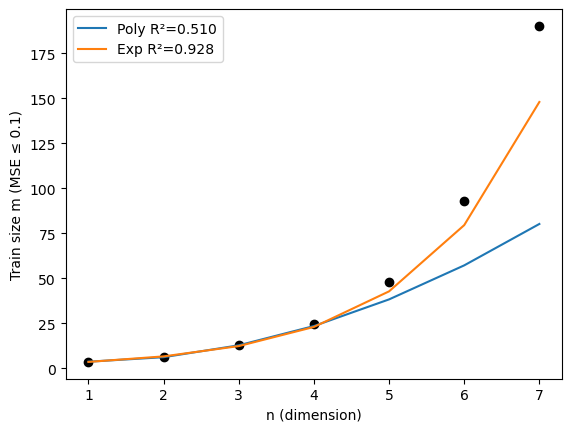

In [43]:
res = fit_scaling(ns, means)

ns = np.asarray(ns)
means = np.asarray(means)

mask = np.isfinite(means)
ns_valid = ns[mask]
means_valid = means[mask]

# Polynomial
poly_pred = np.polyval(res["poly_coeffs"], ns_valid)

# Exponential
exp_pred = res["exp_C"] * res["exp_base"] ** ns_valid

plt.scatter(ns_valid, means_valid, color="k")
plt.plot(ns_valid, poly_pred,
         label=f"Poly R²={res['poly_r2_full']:.3f}")
plt.plot(ns_valid, exp_pred,
         label=f"Exp R²={res['exp_r2_full']:.3f}")

plt.legend()
plt.xlabel("n (dimension)")
plt.ylabel("Train size m (MSE ≤ 0.1)")
plt.show()

In [30]:
import numpy as np
from scipy.stats import linregress
from scipy.optimize import curve_fit


def fit_scaling(ns, ys):
    ns = np.array(ns, dtype=float)
    ys = np.array(ys, dtype=float)

    mask = ys > 0
    ns = ns[mask]
    ys = ys[mask]

    # Exponential fit: y = C a^n
    r1 = linregress(ns, np.log(ys))
    exp_pred = np.exp(r1.intercept + r1.slope*ns)

    # Power law: y = C n^p
    r2 = linregress(np.log(ns), np.log(ys))
    pow_pred = np.exp(r2.intercept) * ns**r2.slope

    
    def r2_score(y, yhat):
        ss_res = np.sum((y-yhat)**2)
        ss_tot = np.sum((y-y.mean())**2)
        return 1 - ss_res/ss_tot

    return {
        "exp_base": np.exp(r1.slope),
        "exp_r2": r2_score(ys, exp_pred),

        "power_p": r2.slope,
        "power_r2": r2_score(ys, pow_pred),
    }
    
    

In [31]:
fit_scaling(range(1,10), [1.0, 2.0, 4.0, 7.0, 14.0, 28.0, 56.0, 111.0, 222.0])

{'exp_base': np.float64(1.9582889883030505),
 'exp_r2': np.float64(0.9987658951924994),
 'power_p': np.float64(2.4372296042082477),
 'power_r2': np.float64(0.6018725338917275)}

In [32]:
def plot_eigs_vs_n():
    plt.figure(figsize=(7,5))

    for lam in LAMBDAS:
        mins, mins_std = [], []
        maxs, maxs_std = [], []
        ns = []

        for n in N_VALUES:
            key = (n, lam, TRAIN_BIAS[0], TEST_BIAS[0])
            if key in all_results:
                mins.append(all_results[key]["eig_stop_min_mean"])
                mins_std.append(all_results[key]["eig_stop_min_std"])
                maxs.append(all_results[key]["eig_stop_max_mean"])
                maxs_std.append(all_results[key]["eig_stop_max_std"])
                ns.append(n)

        plt.errorbar(ns, mins, yerr=mins_std, marker="o", label=f"min λ={lam}")
        plt.errorbar(ns, maxs, yerr=maxs_std, marker="s", linestyle="--", label=f"max λ={lam}")

    plt.yscale("log")
    plt.xlabel("n")
    plt.ylabel("Eigenvalue at stopping")
    plt.title("Kernel Spectrum at Generalization Threshold")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

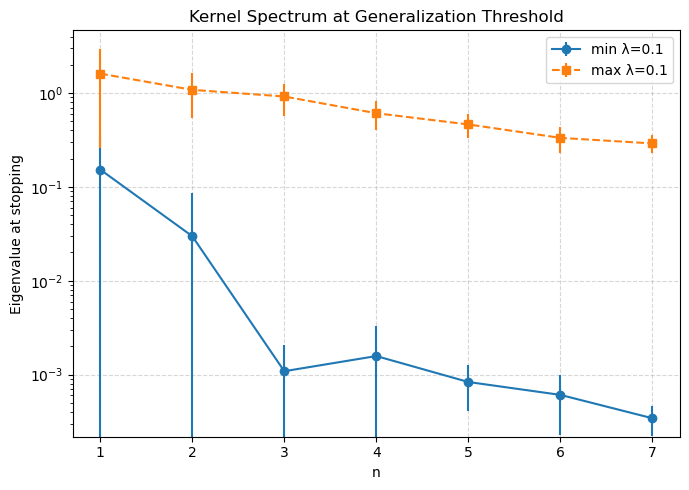

In [33]:
plot_eigs_vs_n()

In [34]:
def plot_eigs_vs_n():
    plt.figure(figsize=(7,5))

    for lam in LAMBDAS:
        mins, mins_std = [], []
        maxs, maxs_std = [], []
        ns = []

        for n in N_VALUES:
            key = (n, lam, TRAIN_BIAS[2], TEST_BIAS[2])
            if key in all_results:
                mins.append(all_results[key]["eig_stop_min_mean"])
                mins_std.append(all_results[key]["eig_stop_min_std"])
                maxs.append(all_results[key]["eig_stop_max_mean"])
                maxs_std.append(all_results[key]["eig_stop_max_std"])
                ns.append(n)

        plt.errorbar(ns, mins, yerr=mins_std, marker="o", label=f"min λ={lam}")
        plt.errorbar(ns, maxs, yerr=maxs_std, marker="s", linestyle="--", label=f"max λ={lam}")

    # plt.yscale("log")
    plt.xlabel("n")
    plt.ylabel("Eigenvalue at stopping")
    plt.title("Kernel Spectrum at Generalization Threshold")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
plot_eigs_vs_n()


IndexError: list index out of range

<Figure size 700x500 with 0 Axes>

In [ ]:
def one_d_factor(x, alpha_j, r=3):
    theta = alpha_j/(2*r)
    phi = x/(2*r)

    ct2 = np.cos(theta)**2
    ct4 = ct2**2
    ct6 = ct2**3

    cp2 = np.cos(phi)**2
    cp4 = cp2**2

    return (
        32*cp4*ct6
        -32*cp4*ct4
        -16*cp2*ct4
        +16*cp2*ct2
        +2*ct2
        -1
    )



def get_centers_for_alpha(alpha_j, num_centers=5):
    grid = np.linspace(-3*np.pi, 3*np.pi, 20000)
    vals = one_d_factor(grid, alpha_j)

    max_idx, _ = find_peaks(vals)
    min_idx, _ = find_peaks(-vals)

    peaks = np.concatenate([max_idx, min_idx])

    # fallback if no peaks
    if len(peaks) == 0:
        peaks = np.array([np.argmax(np.abs(vals))])

    peaks = sorted(peaks, key=lambda i: abs(vals[i]), reverse=True)

    chosen = []
    min_sep = 0.01

    for idx in peaks:
        x = grid[idx]

        if all(abs(x-c) > min_sep for c in chosen):
            chosen.append(x)

        if len(chosen) == num_centers:
            break

    return np.array(chosen)

def sample_biased_x(num_points, dim_x, alpha):
    sigma = 0.4 / np.sqrt(dim_x)

    centers_per_dim = [get_centers_for_alpha(a) for a in alpha]

    samples = np.zeros((num_points, dim_x))

    for i in range(num_points):
        for j in range(dim_x):
            centers_j = centers_per_dim[j]
            k = np.random.randint(len(centers_j))
            c = centers_j[k]
            samples[i, j] = np.random.normal(c, sigma)

    return samples

def generate_mixed_dataset(num_points, dim_x, alpha, bias_fraction):
    n_bias = int(num_points * bias_fraction)
    n_uniform = num_points - n_bias

    xs_uniform = np.random.uniform(-3*np.pi, 3*np.pi, (n_uniform, dim_x))
    xs_bias = sample_biased_x(n_bias, dim_x, alpha)

    xs = np.vstack([xs_uniform, xs_bias])
    np.random.shuffle(xs)

    X = [x for x in xs]
    Y = np.array([analytic_function(x, alpha) for x in X])
    return X, Y


In [ ]:
def get_alpha_from_seed(seed, dim_x):
    np.random.seed(seed)
    return 3*np.pi * np.random.rand(dim_x)

In [ ]:
def inspect_seed(seed, dim_x):
    alpha = get_alpha_from_seed(seed, dim_x)

    grid = np.linspace(-3*np.pi, 3*np.pi, 3000)

    plt.figure(figsize=(14,8))

    for j in range(min(dim_x,6)):   # first 6 coords
        vals = one_d_factor(grid, alpha[j])
        plt.plot(grid, vals, label=f"j={j}")

    plt.title(f"1D factors for seed={seed}, n={dim_x}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
def inspect_coordinate(seed, dim_x, coord=0):
    alpha = get_alpha_from_seed(seed, dim_x)
    a = alpha[coord]

    grid = np.linspace(-3*np.pi, 3*np.pi, 3000)
    vals = one_d_factor(grid, a)

    centers = get_centers_for_alpha(a)

    samples = sample_biased_x(
        num_points=300,
        dim_x=1,
        alpha=np.array([a])
    ).flatten()

    sample_vals = one_d_factor(samples, a)

    plt.figure(figsize=(12,6))

    plt.plot(grid, vals, lw=2, label="factor")

    plt.scatter(
        centers,
        one_d_factor(centers, a),
        s=120,
        marker="x",
        label="centers"
    )

    plt.scatter(
        samples,
        sample_vals,
        alpha=0.4,
        s=20,
        label="samples"
    )

    plt.title(f"seed={seed}, n={dim_x}, coord={coord}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

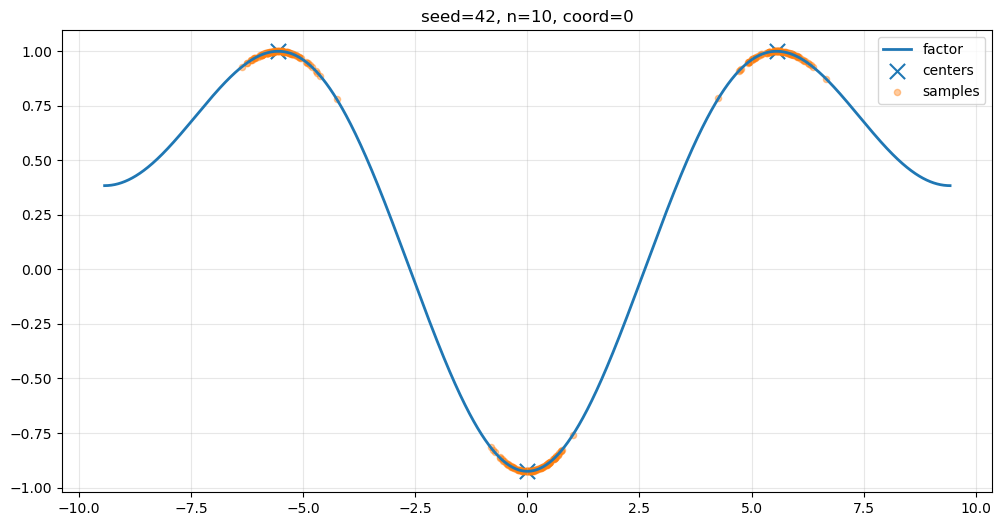

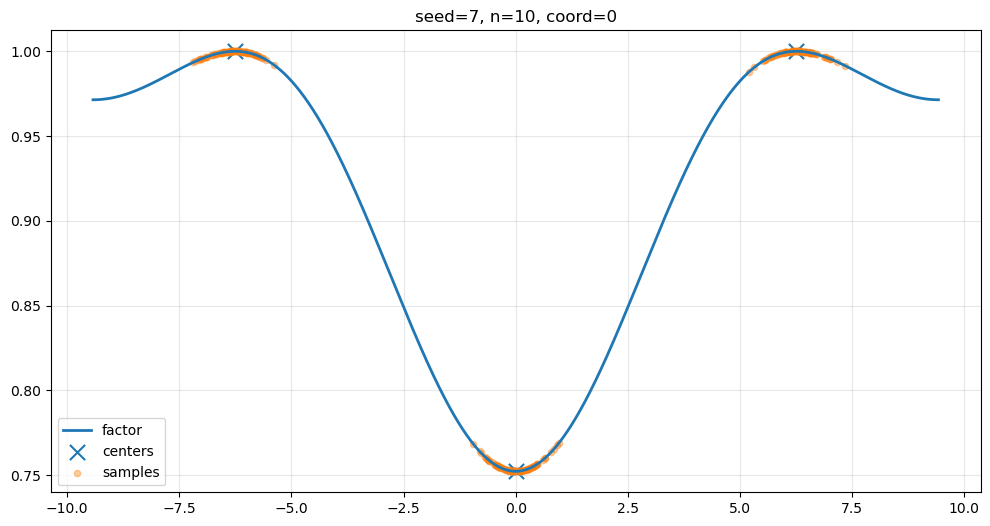

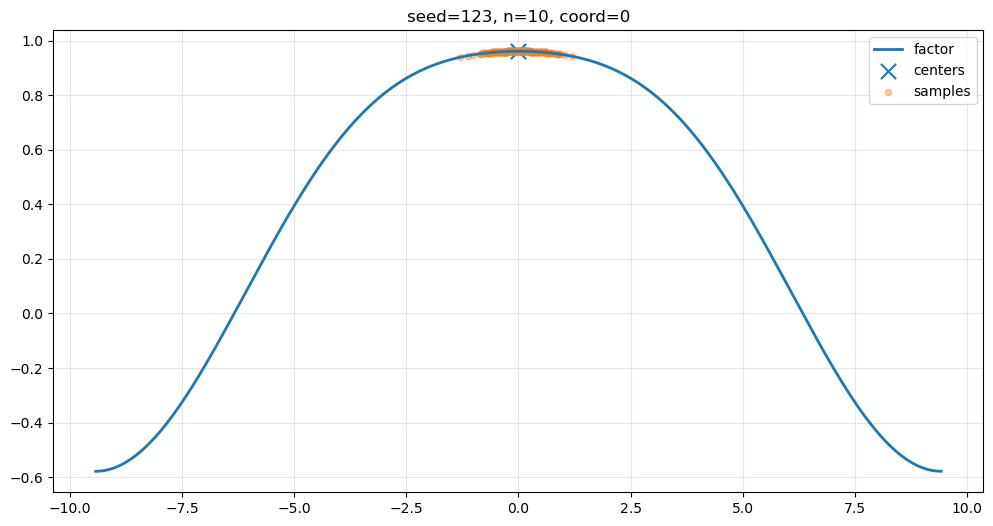

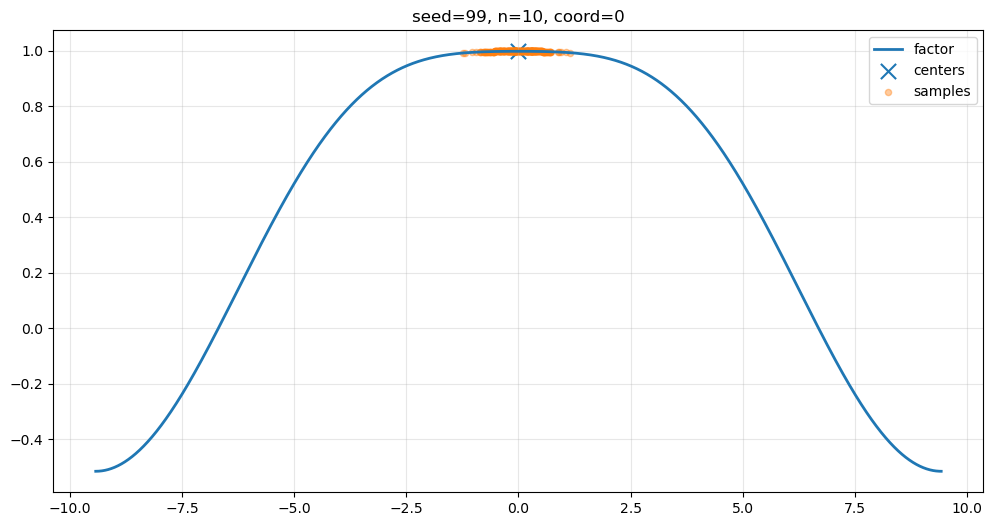

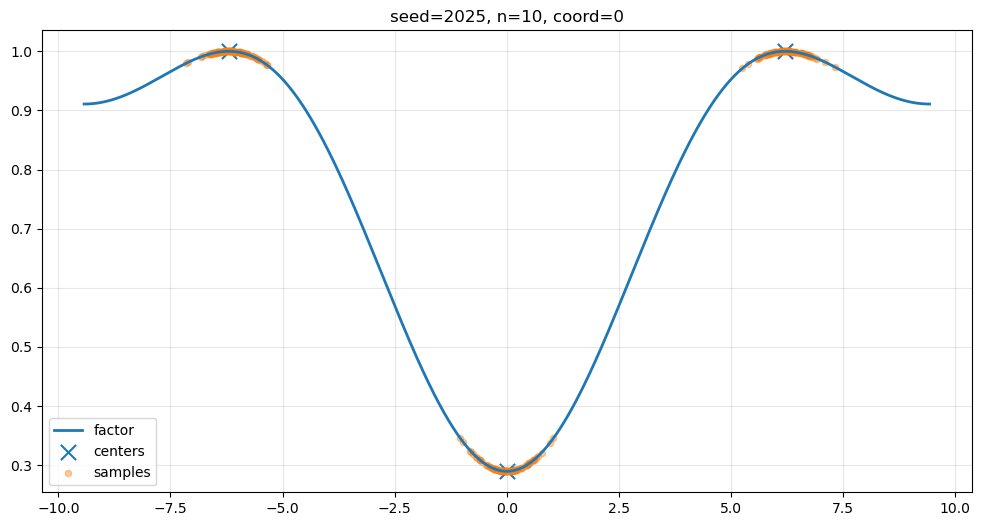

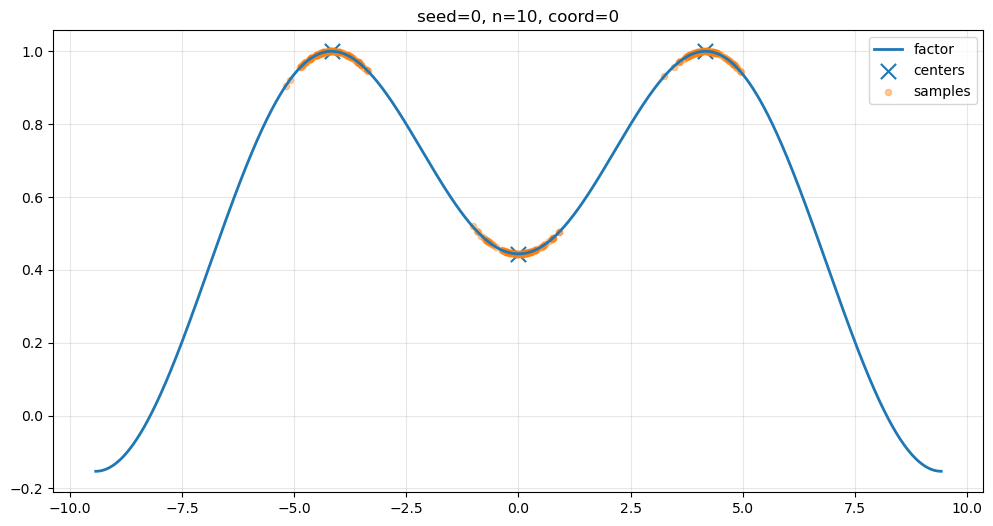

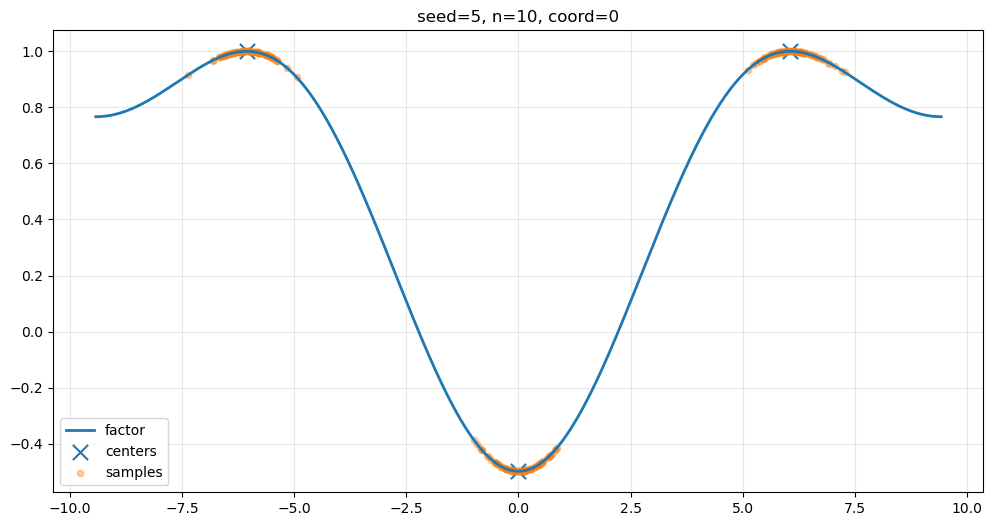

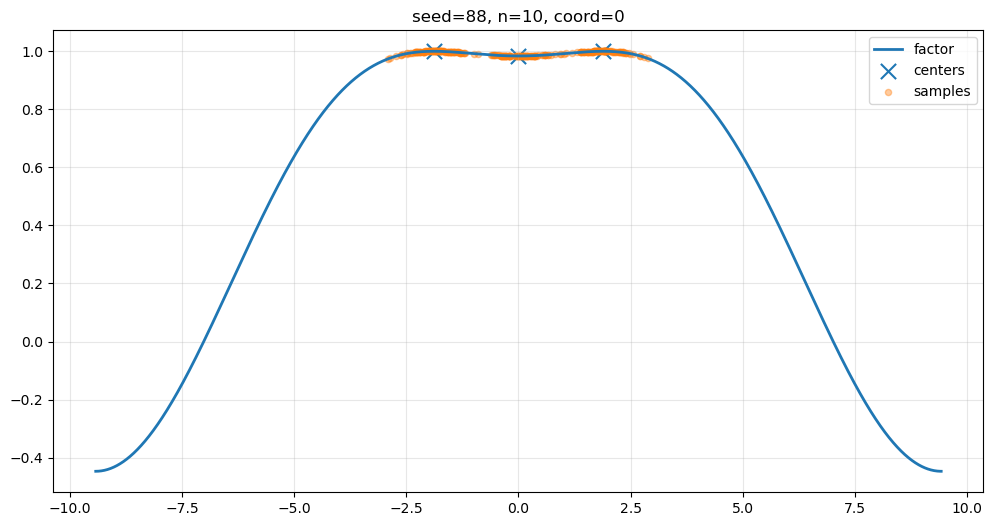

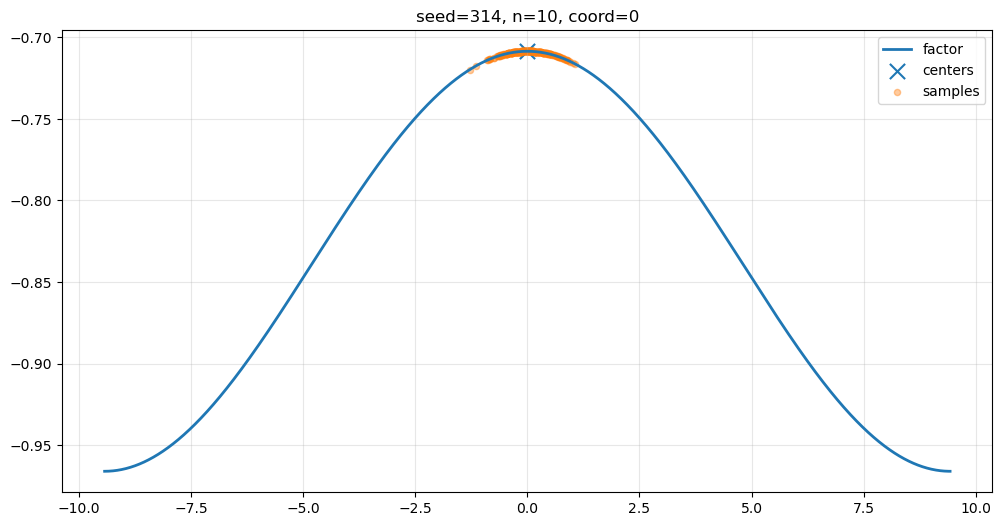

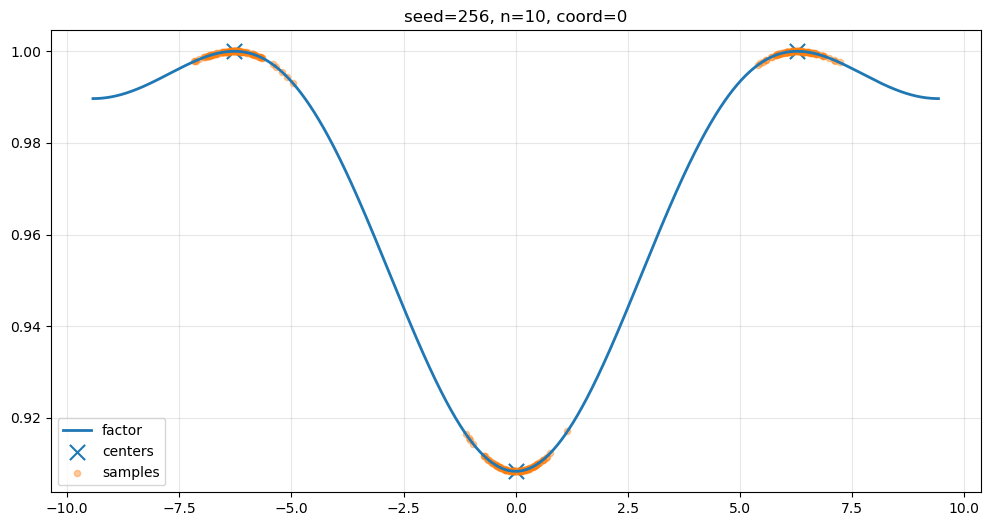

In [ ]:
for seed in SEEDS:
    inspect_coordinate(seed, 10, 0)